In [1]:
%matplotlib inline

import intake

import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import cartopy.crs as ccrs
import xarray as xr
import cmocean.cm as cmocean
import glob
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.path as mpath
import matplotlib.colors as col
import matplotlib.pyplot as pyplot

from netCDF4 import Dataset

import xesmf as xe

import warnings

from os import environ
environ["PYTHONWARNINGS"] = "ignore"

import logging
logging.captureWarnings(True)
logging.getLogger('py.warnings').setLevel(logging.ERROR)

from dask.distributed import Client

# figdir = '/g/data/e14/pc5520/figures/basal_melt_param/'
figdir = '/g/data/e14/fbd581/basal_mom5-collaborative-project/figures/'

In [2]:
client = Client(threads_per_worker=1)
client.dashboard_link

'/proxy/36697/status'

In [3]:
# add experiments to my own intake:

# - control:
path_ctrl = "/g/data/v45/wf4500/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW"

# - basal No Gade: GPC029 (Basal)   
path_noBG = '/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb'

# - basal Gade: GPC023 (Basal_LH)   
path_BG = '/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb'

# - basal Gade Brine: GPC062 (Basal_LH_Brine)    
path_BGB = '/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine'


In [4]:
from access_nri_intake.source.builders import AccessOm2Builder


In [5]:
%%time

builder = AccessOm2Builder(
    path=path_ctrl
).build()

builder.save(
    name="DSW_control", 
    description="An example datastore for ACCESS-OM2 ryf9091 DSW control",
)

Successfully wrote ESM catalog json file to: file:///home/581/fbd581/DSW_control.json
CPU times: user 12.7 s, sys: 3.78 s, total: 16.5 s
Wall time: 1min 25s


In [6]:
%%time

builder = AccessOm2Builder(
    path=path_noBG
).build()

builder.save(
    name="Basal", 
    description="Datastore for ACCESS-OM2 ryf9091 Basal",
)

Successfully wrote ESM catalog json file to: file:///home/581/fbd581/Basal.json
CPU times: user 6 s, sys: 3.82 s, total: 9.82 s
Wall time: 20.3 s


In [7]:
%%time

builder = AccessOm2Builder(
    path=path_BG
).build()

builder.save(
    name="Basal_LH", 
    description="Datastore for ACCESS-OM2 ryf9091 Basal_LH",
)

Successfully wrote ESM catalog json file to: file:///home/581/fbd581/Basal_LH.json
CPU times: user 3.05 s, sys: 1.76 s, total: 4.81 s
Wall time: 10 s


In [8]:
%%time

builder = AccessOm2Builder(
    path=path_BGB
).build()

builder.save(
    name="Basal_LH_Brine", 
    description="Datastore for ACCESS-OM2 ryf9091 Basal_LH_Brine",
)

Successfully wrote ESM catalog json file to: file:///home/581/fbd581/Basal_LH_Brine.json
CPU times: user 3.73 s, sys: 2.3 s, total: 6.03 s
Wall time: 13 s


In [9]:
cat = intake.open_esm_datastore(
    "./DSW_control.json",
    columns_with_iterables=["variable"] # This is important
)
# ds = cat.search(variable="temp").to_dask()

cat_noBG = intake.open_esm_datastore(
    "./Basal.json",
    columns_with_iterables=["variable"] # This is important
)

cat_BG = intake.open_esm_datastore(
    "./Basal_LH.json",
    columns_with_iterables=["variable"] # This is important
)

cat_BGB = intake.open_esm_datastore(
    "./Basal_LH_Brine.json",
    columns_with_iterables=["variable"] # This is important
)

In [10]:
%%time
# Make sure these match the available restarts:
start_time='1907-01-01'
end_time='1909-12-31'
lat_slice  = slice(-80,-59)


CPU times: user 3 μs, sys: 7 μs, total: 10 μs
Wall time: 16.2 μs


In [11]:
%%time

# load surface heat flux from different components:
d1 = cat.search(variable='sfc_hflux_from_runoff', frequency='1mon').to_dask()
sfc_hflux_from_runoff_ctrl = d1.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d2 = cat.search(variable='sfc_hflux_coupler', frequency='1mon').to_dask()
sfc_hflux_coupler_ctrl = d2.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d3 = cat.search(variable='sfc_hflux_pme', frequency='1mon').to_dask()
sfc_hflux_pme_ctrl = d3.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d4 = cat.search(variable='frazil_3d_int_z', frequency='1mon').to_dask()
frazil_3d_int_z_ctrl = d4.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d5 = cat.search(variable='swflx', frequency='1mon').to_dask()
swflx_ctrl = d5.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d6 = cat.search(variable='lw_heat', frequency='1mon').to_dask()
lw_heat_ctrl = d6.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d7 = cat.search(variable='sens_heat', frequency='1mon').to_dask()
sens_heat_ctrl = d7.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d8 = cat.search(variable='evap_heat', frequency='1mon').to_dask()
evap_heat_ctrl = d8.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d9 = cat.search(variable='fprec_melt_heat', frequency='1mon').to_dask()
fprec_melt_heat_ctrl = d9.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

mhflux_ctrl = sfc_hflux_coupler_ctrl.to_dataarray().squeeze() - \
            (swflx_ctrl.to_dataarray().squeeze() +lw_heat_ctrl .to_dataarray().squeeze() + \
             sens_heat_ctrl.to_dataarray().squeeze() +evap_heat_ctrl.to_dataarray().squeeze() + \
             fprec_melt_heat_ctrl.to_dataarray().squeeze())


CPU times: user 4.3 s, sys: 875 ms, total: 5.17 s
Wall time: 21.3 s


In [12]:
%%time

# load surface heat flux from different components:
d1 = cat_noBG.search(variable='sfc_hflux_from_runoff', frequency='1mon').to_dask()
sfc_hflux_from_runoff_noBG = d1.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d2 = cat_noBG.search(variable='sfc_hflux_coupler', frequency='1mon').to_dask()
sfc_hflux_coupler_noBG = d2.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d3 = cat_noBG.search(variable='sfc_hflux_pme', frequency='1mon').to_dask()
sfc_hflux_pme_noBG = d3.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d4 = cat_noBG.search(variable='frazil_3d_int_z', frequency='1mon').to_dask()
frazil_3d_int_z_noBG = d4.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d5 = cat_noBG.search(variable='swflx', frequency='1mon').to_dask()
swflx_noBG = d5.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d6 = cat_noBG.search(variable='lw_heat', frequency='1mon').to_dask()
lw_heat_noBG = d6.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d7 = cat_noBG.search(variable='sens_heat', frequency='1mon').to_dask()
sens_heat_noBG = d7.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d8 = cat_noBG.search(variable='evap_heat', frequency='1mon').to_dask()
evap_heat_noBG = d8.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d9 = cat_noBG.search(variable='fprec_melt_heat', frequency='1mon').to_dask()
fprec_melt_heat_noBG = d9.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

mhflux_noBG = sfc_hflux_coupler_noBG.to_dataarray().squeeze() - \
            (swflx_noBG.to_dataarray().squeeze() +lw_heat_noBG .to_dataarray().squeeze() + \
             sens_heat_noBG.to_dataarray().squeeze() +evap_heat_noBG.to_dataarray().squeeze() + \
             fprec_melt_heat_noBG.to_dataarray().squeeze())

d10 = cat_noBG.search(variable='temp_basalmix', frequency='1mon').to_dask()
temp_basalmix_noBG = d10.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d11 = cat_noBG.search(variable='temp_icbmix', frequency='1mon').to_dask()
temp_icbmix_noBG = d11.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)


CPU times: user 11.8 s, sys: 1.21 s, total: 13 s
Wall time: 20.7 s


In [13]:
%%time

# load surface heat flux from different components:
d1 = cat_BG.search(variable='sfc_hflux_from_runoff', frequency='1mon').to_dask()
sfc_hflux_from_runoff_BG = d1.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d2 = cat_BG.search(variable='sfc_hflux_coupler', frequency='1mon').to_dask()
sfc_hflux_coupler_BG = d2.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d3 = cat_BG.search(variable='sfc_hflux_pme', frequency='1mon').to_dask()
sfc_hflux_pme_BG = d3.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d4 = cat_BG.search(variable='frazil_3d_int_z', frequency='1mon').to_dask()
frazil_3d_int_z_BG = d4.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d5 = cat_BG.search(variable='swflx', frequency='1mon').to_dask()
swflx_BG = d5.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d6 = cat_BG.search(variable='lw_heat', frequency='1mon').to_dask()
lw_heat_BG = d6.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d7 = cat_BG.search(variable='sens_heat', frequency='1mon').to_dask()
sens_heat_BG = d7.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d8 = cat_BG.search(variable='evap_heat', frequency='1mon').to_dask()
evap_heat_BG = d8.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d9 = cat_BG.search(variable='fprec_melt_heat', frequency='1mon').to_dask()
fprec_melt_heat_BG = d9.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

mhflux_BG = sfc_hflux_coupler_BG.to_dataarray().squeeze() - \
            (swflx_BG.to_dataarray().squeeze() +lw_heat_BG .to_dataarray().squeeze() + \
             sens_heat_BG.to_dataarray().squeeze() +evap_heat_BG.to_dataarray().squeeze() + \
             fprec_melt_heat_BG.to_dataarray().squeeze())

d10 = cat_BG.search(variable='temp_basalmix', frequency='1mon').to_dask()
temp_basalmix_BG = d10.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d11 = cat_BG.search(variable='temp_icbmix', frequency='1mon').to_dask()
temp_icbmix_BG = d11.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)



CPU times: user 6.01 s, sys: 631 ms, total: 6.64 s
Wall time: 9.97 s


In [14]:
%%time

# load surface heat flux from different components:
d1 = cat_BGB.search(variable='sfc_hflux_from_runoff', frequency='1mon').to_dask()
sfc_hflux_from_runoff_BGB = d1.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d2 = cat_BGB.search(variable='sfc_hflux_coupler', frequency='1mon').to_dask()
sfc_hflux_coupler_BGB = d2.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d3 = cat_BGB.search(variable='sfc_hflux_pme', frequency='1mon').to_dask()
sfc_hflux_pme_BGB = d3.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d4 = cat_BGB.search(variable='frazil_3d_int_z', frequency='1mon').to_dask()
frazil_3d_int_z_BGB = d4.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d5 = cat_BGB.search(variable='swflx', frequency='1mon').to_dask()
swflx_BGB = d5.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d6 = cat_BGB.search(variable='lw_heat', frequency='1mon').to_dask()
lw_heat_BGB = d6.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d7 = cat_BGB.search(variable='sens_heat', frequency='1mon').to_dask()
sens_heat_BGB = d7.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d8 = cat_BGB.search(variable='evap_heat', frequency='1mon').to_dask()
evap_heat_BGB = d8.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d9 = cat_BGB.search(variable='fprec_melt_heat', frequency='1mon').to_dask()
fprec_melt_heat_BGB = d9.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

mhflux_BGB = sfc_hflux_coupler_BGB.to_dataarray().squeeze() - \
            (swflx_BGB.to_dataarray().squeeze() +lw_heat_BGB .to_dataarray().squeeze() + \
             sens_heat_BGB.to_dataarray().squeeze() +evap_heat_BGB.to_dataarray().squeeze() + \
             fprec_melt_heat_BGB.to_dataarray().squeeze())

d10 = cat_BGB.search(variable='temp_basalmix', frequency='1mon').to_dask()
temp_basalmix_BGB = d10.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

# d11 = cat_BGB.search(variable='temp_icbmix', frequency='1mon').to_dask()
# temp_icbmix_BGB = d11.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)



CPU times: user 6.28 s, sys: 661 ms, total: 6.94 s
Wall time: 10.6 s


In [15]:
d1 = cat.search(variable="area_t",path='/g/data/v45/wf4500/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW/output000/ocean/ocean_grid.nc').to_dask()
oc_grd = d1.sel(yt_ocean=lat_slice)
area_t = oc_grd.area_t

d2 = cat.search(variable="ht",path='/g/data/v45/wf4500/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW/output000/ocean/ocean_grid.nc').to_dask()
oc_grd = d2.sel(yt_ocean=lat_slice)
ht = oc_grd.ht

land_mask = np.squeeze(ht)*0
land_mask_fld = land_mask.fillna(1)
land_mask_fld = np.where(land_mask_fld==1,land_mask_fld,np.nan)
land_mask_masked = np.ma.masked_where((land_mask_fld==0),land_mask_fld)

# make land go all the way to -90S:
land_mask_lat = ht.yt_ocean.values
land_mask_lat[0] = -90

fontsize=15

In [16]:
%%time
import numpy.ma as ma

# function to do annual avg and horiz. integral: ONLY SHELF
def var_tavg_hint_shelf(var2d):
    var = var2d.mean('time') # annual mean
    var_masked = ma.masked_where(ht > 1000, var) # masked offshore 1000m isobath
    var_masked_area = var_masked*area_t # multiply by area
    var_hint = np.nansum(np.nansum(var_masked_area, axis=1), axis=0) # sum along x/y axis

    return var_hint

# function to do ONLY horiz. integral: ONLY SHELF
def var_hint_shelf(var2d):
    var_masked = ma.masked_where(ht > 1000, var2d) # masked offshore 1000m isobath
    var_masked_area = var_masked*area_t # multiply by area
    var_hint = np.nansum(np.nansum(var_masked_area, axis=1), axis=0) # sum along x/y axis

    return var_hint

# function to do annual avg and horiz. integral: GLOBAL
def var_tavg_hint(var2d):
    var = var2d.mean('time') # annual mean
    var_area = var*area_t # multiply by area
    var_hint = np.nansum(np.nansum(var_area, axis=1), axis=0) # sum along x/y axis

    return var_hint

CPU times: user 7 μs, sys: 7 μs, total: 14 μs
Wall time: 20.7 μs


In [17]:
%%time

# Control experiment:

# self-only
HF_runoff_annual_hint_shelf_ctrl = var_tavg_hint_shelf(sfc_hflux_from_runoff_ctrl.to_dataarray().squeeze())
HF_coupler_annual_hint_shelf_ctrl = var_tavg_hint_shelf(sfc_hflux_coupler_ctrl.to_dataarray().squeeze())
HF_pme_annual_hint_shelf_ctrl = var_tavg_hint_shelf(sfc_hflux_pme_ctrl.to_dataarray().squeeze())
HF_frazil_annual_hint_shelf_ctrl = var_tavg_hint_shelf(frazil_3d_int_z_ctrl.to_dataarray().squeeze())
HF_sw_annual_hint_shelf_ctrl = var_tavg_hint_shelf(swflx_ctrl.to_dataarray().squeeze())
HF_lw_annual_hint_shelf_ctrl = var_tavg_hint_shelf(lw_heat_ctrl.to_dataarray().squeeze())
HF_sens_annual_hint_shelf_ctrl = var_tavg_hint_shelf(sens_heat_ctrl.to_dataarray().squeeze())
HF_evap_annual_hint_shelf_ctrl = var_tavg_hint_shelf(evap_heat_ctrl.to_dataarray().squeeze())
HF_fprec_annual_hint_shelf_ctrl = var_tavg_hint_shelf(fprec_melt_heat_ctrl.to_dataarray().squeeze())
HF_mh_annual_hint_shelf_ctrl = var_tavg_hint_shelf(mhflux_ctrl)


CPU times: user 9.41 s, sys: 1.09 s, total: 10.5 s
Wall time: 19.4 s


In [18]:
%%time

# Basal_NOgade experiment:

# shelf-only
HF_runoff_annual_hint_shelf_noBG = var_tavg_hint_shelf(sfc_hflux_from_runoff_noBG.to_dataarray().squeeze())
HF_coupler_annual_hint_shelf_noBG = var_tavg_hint_shelf(sfc_hflux_coupler_noBG.to_dataarray().squeeze())
HF_pme_annual_hint_shelf_noBG = var_tavg_hint_shelf(sfc_hflux_pme_noBG.to_dataarray().squeeze())
HF_frazil_annual_hint_shelf_noBG = var_tavg_hint_shelf(frazil_3d_int_z_noBG.to_dataarray().squeeze())
HF_sw_annual_hint_shelf_noBG = var_tavg_hint_shelf(swflx_noBG.to_dataarray().squeeze())
HF_lw_annual_hint_shelf_noBG = var_tavg_hint_shelf(lw_heat_noBG.to_dataarray().squeeze())
HF_sens_annual_hint_shelf_noBG = var_tavg_hint_shelf(sens_heat_noBG.to_dataarray().squeeze())
HF_evap_annual_hint_shelf_noBG = var_tavg_hint_shelf(evap_heat_noBG.to_dataarray().squeeze())
HF_fprec_annual_hint_shelf_noBG = var_tavg_hint_shelf(fprec_melt_heat_noBG.to_dataarray().squeeze())

# first get vertical sum of basal mix:
HF_basalmix_annual_vint_noBG = temp_basalmix_noBG.sum('st_ocean')

HF_basalmix_annual_hint_shelf_noBG = var_tavg_hint_shelf(HF_basalmix_annual_vint_noBG.to_dataarray().squeeze())
HF_mh_annual_hint_shelf_noBG = var_tavg_hint_shelf(mhflux_noBG)

CPU times: user 56.9 s, sys: 3.29 s, total: 1min
Wall time: 1min 16s


In [19]:
%%time

# Basal_gade experiment:

# shelf-only
HF_runoff_annual_hint_shelf_BG = var_tavg_hint_shelf(sfc_hflux_from_runoff_BG.to_dataarray().squeeze())
HF_coupler_annual_hint_shelf_BG = var_tavg_hint_shelf(sfc_hflux_coupler_BG.to_dataarray().squeeze())
HF_pme_annual_hint_shelf_BG = var_tavg_hint_shelf(sfc_hflux_pme_BG.to_dataarray().squeeze())
HF_frazil_annual_hint_shelf_BG = var_tavg_hint_shelf(frazil_3d_int_z_BG.to_dataarray().squeeze())
HF_sw_annual_hint_shelf_BG = var_tavg_hint_shelf(swflx_BG.to_dataarray().squeeze())
HF_lw_annual_hint_shelf_BG = var_tavg_hint_shelf(lw_heat_BG.to_dataarray().squeeze())
HF_sens_annual_hint_shelf_BG = var_tavg_hint_shelf(sens_heat_BG.to_dataarray().squeeze())
HF_evap_annual_hint_shelf_BG = var_tavg_hint_shelf(evap_heat_BG.to_dataarray().squeeze())
HF_fprec_annual_hint_shelf_BG = var_tavg_hint_shelf(fprec_melt_heat_BG.to_dataarray().squeeze())

# first get vertical sum of basal mix:
HF_basalmix_annual_vint_BG = temp_basalmix_BG.sum('st_ocean')

HF_basalmix_annual_hint_shelf_BG = var_tavg_hint_shelf(HF_basalmix_annual_vint_BG.to_dataarray().squeeze())
HF_mh_annual_hint_shelf_BG = var_tavg_hint_shelf(mhflux_BG)

CPU times: user 56.8 s, sys: 3.09 s, total: 59.9 s
Wall time: 1min 14s


In [20]:
%%time

# Basal_gade_brine experiment:

# shelf-only
HF_runoff_annual_hint_shelf_BGB = var_tavg_hint_shelf(sfc_hflux_from_runoff_BGB.to_dataarray().squeeze())
HF_coupler_annual_hint_shelf_BGB = var_tavg_hint_shelf(sfc_hflux_coupler_BGB.to_dataarray().squeeze())
HF_pme_annual_hint_shelf_BGB = var_tavg_hint_shelf(sfc_hflux_pme_BGB.to_dataarray().squeeze())
HF_frazil_annual_hint_shelf_BGB = var_tavg_hint_shelf(frazil_3d_int_z_BGB.to_dataarray().squeeze())
HF_sw_annual_hint_shelf_BGB = var_tavg_hint_shelf(swflx_BGB.to_dataarray().squeeze())
HF_lw_annual_hint_shelf_BGB = var_tavg_hint_shelf(lw_heat_BGB.to_dataarray().squeeze())
HF_sens_annual_hint_shelf_BGB = var_tavg_hint_shelf(sens_heat_BGB.to_dataarray().squeeze())
HF_evap_annual_hint_shelf_BGB = var_tavg_hint_shelf(evap_heat_BGB.to_dataarray().squeeze())
HF_fprec_annual_hint_shelf_BGB = var_tavg_hint_shelf(fprec_melt_heat_BGB.to_dataarray().squeeze())

# first get vertical sum of basal mix:
HF_basalmix_annual_vint_BGB = temp_basalmix_BGB.sum('st_ocean')

HF_basalmix_annual_hint_shelf_BGB = var_tavg_hint_shelf(HF_basalmix_annual_vint_BGB.to_dataarray().squeeze())
HF_mh_annual_hint_shelf_BGB = var_tavg_hint_shelf(mhflux_BGB)

CPU times: user 58.8 s, sys: 3.17 s, total: 1min 1s
Wall time: 1min 15s


In [21]:
# %%time

# # Basal+Iceberg experiment:

# # # first get vertical sum of basal and icb mix:
# HF_basalmix_annual_vint_ICB = np.sum(temp_basalmix_ICB, axis=1)
# HF_icbmix_annual_vint_ICB = np.sum(temp_icbmix_ICB, axis=1)

# # shelf-only
# HF_runoff_annual_hint_shelf_ICB = var_tavg_hint_shelf(sfc_hflux_from_runoff_ICB)
# HF_coupler_annual_hint_shelf_ICB = var_tavg_hint_shelf(sfc_hflux_coupler_ICB)
# HF_pme_annual_hint_shelf_ICB = var_tavg_hint_shelf(sfc_hflux_pme_ICB)
# HF_frazil_annual_hint_shelf_ICB = var_tavg_hint_shelf(frazil_3d_int_z_ICB)
# HF_sw_annual_hint_shelf_ICB = var_tavg_hint_shelf(swflx_ICB)
# HF_lw_annual_hint_shelf_ICB = var_tavg_hint_shelf(lw_heat_ICB)
# HF_sens_annual_hint_shelf_ICB = var_tavg_hint_shelf(sens_heat_ICB)
# HF_evap_annual_hint_shelf_ICB = var_tavg_hint_shelf(evap_heat_ICB)
# HF_fprec_annual_hint_shelf_ICB = var_tavg_hint_shelf(fprec_melt_heat_ICB)

# HF_basalmix_annual_hint_shelf_ICB = var_tavg_hint_shelf(HF_basalmix_annual_vint_ICB)
# HF_icbmix_annual_hint_shelf_ICB = var_tavg_hint_shelf(HF_icbmix_annual_vint_ICB)
# HF_mh_annual_hint_shelf_ICB = var_tavg_hint_shelf(mhflux_ICB)


In [22]:
# # plot with bars: last year annual avg, horizontally-integrated (over the shelf , depth<1000m only):
# fig, ax  = plt.subplots(figsize = (11,6))

# pyplot.bar(0.8, HF_runoff_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k', label='Control')
# pyplot.bar(1, HF_runoff_annual_hint_shelf_noBG*1e-12, width=0.2, color='#DDAA33', label='Basal')
# pyplot.bar(1.2, HF_runoff_annual_hint_shelf_BG*1e-12, width=0.2, color='#BB5566', label='Basal_LH')
# pyplot.bar(1.4, HF_runoff_annual_hint_shelf_BGB*1e-12, width=0.2, color='steelblue', label='Basal_LH_Brine')

# plt.legend(fontsize=20)

# pyplot.bar(1.8, HF_coupler_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k', label='Control')
# pyplot.bar(2, HF_coupler_annual_hint_shelf_noBG*1e-12, width=0.2, color='#DDAA33', label='Basal')
# pyplot.bar(2.2, HF_coupler_annual_hint_shelf_BG*1e-12, width=0.2, color='#BB5566', label='Basal_LH')
# pyplot.bar(2.4, HF_coupler_annual_hint_shelf_BGB*1e-12, width=0.2, color='steelblue', label='Basal_LH_Brine')

# pyplot.bar(2.8, HF_sw_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
# pyplot.bar(3, HF_sw_annual_hint_shelf_noBG*1e-12, width=0.2, color='#DDAA33')
# pyplot.bar(3.2, HF_sw_annual_hint_shelf_BG*1e-12, width=0.2, color='#BB5566')
# pyplot.bar(3.4, HF_sw_annual_hint_shelf_BGB*1e-12, width=0.2, color='steelblue')

# pyplot.bar(3.8, HF_lw_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
# pyplot.bar(4., HF_lw_annual_hint_shelf_noBG*1e-12, width=0.2, color='#DDAA33')
# pyplot.bar(4.2, HF_lw_annual_hint_shelf_BG*1e-12, width=0.2, color='#BB5566')
# pyplot.bar(4.4, HF_lw_annual_hint_shelf_BGB*1e-12, width=0.2, color='steelblue')

# pyplot.bar(4.8, HF_sens_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
# pyplot.bar(5., HF_sens_annual_hint_shelf_noBG*1e-12, width=0.2, color='#DDAA33')
# pyplot.bar(5.2, HF_sens_annual_hint_shelf_BG*1e-12, width=0.2, color='#BB5566')
# pyplot.bar(5.4, HF_sens_annual_hint_shelf_BGB*1e-12, width=0.2, color='steelblue')

# pyplot.bar(5.8, HF_evap_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
# pyplot.bar(6., HF_evap_annual_hint_shelf_noBG*1e-12, width=0.2, color='#DDAA33')
# pyplot.bar(6.2, HF_evap_annual_hint_shelf_BG*1e-12, width=0.2, color='#BB5566')
# pyplot.bar(6.4, HF_evap_annual_hint_shelf_BGB*1e-12, width=0.2, color='steelblue')

# pyplot.bar(6.8, HF_fprec_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
# pyplot.bar(7., HF_fprec_annual_hint_shelf_noBG*1e-12, width=0.2, color='#DDAA33')
# pyplot.bar(7.2, HF_fprec_annual_hint_shelf_BG*1e-12, width=0.2, color='#BB5566')
# pyplot.bar(7.4, HF_fprec_annual_hint_shelf_BGB*1e-12, width=0.2, color='steelblue')

# pyplot.bar(7.8, HF_mh_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
# pyplot.bar(8, HF_mh_annual_hint_shelf_noBG*1e-12, width=0.2, color='#DDAA33')
# pyplot.bar(8.2, HF_mh_annual_hint_shelf_BG*1e-12, width=0.2, color='#BB5566')
# pyplot.bar(8.4, HF_mh_annual_hint_shelf_BGB*1e-12, width=0.2, color='steelblue')

# pyplot.bar(9, HF_basalmix_annual_hint_shelf_noBG*1e-12, width=0.2, color='#DDAA33')
# pyplot.bar(9.2, HF_basalmix_annual_hint_shelf_BG*1e-12, width=0.2, color='#BB5566')
# pyplot.bar(9.4, HF_basalmix_annual_hint_shelf_BGB*1e-12, width=0.2, color='steelblue')

# pyplot.bar(9.8, HF_pme_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
# pyplot.bar(10, HF_pme_annual_hint_shelf_noBG*1e-12, width=0.2, color='#DDAA33')
# pyplot.bar(10.2, HF_pme_annual_hint_shelf_BG*1e-12, width=0.2, color='#BB5566')
# pyplot.bar(10.4, HF_pme_annual_hint_shelf_BGB*1e-12, width=0.2, color='steelblue')

# pyplot.bar(10.8, HF_frazil_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
# pyplot.bar(11, HF_frazil_annual_hint_shelf_noBG*1e-12, width=0.2, color='#DDAA33')
# pyplot.bar(11.2, HF_frazil_annual_hint_shelf_BG*1e-12, width=0.2, color='#BB5566')
# pyplot.bar(11.4, HF_frazil_annual_hint_shelf_BGB*1e-12, width=0.2, color='steelblue')

# ### calculate NET SHF:
# HF_net_annual_hint_shelf_ctrl = HF_runoff_annual_hint_shelf_ctrl+HF_coupler_annual_hint_shelf_ctrl+\
#     HF_pme_annual_hint_shelf_ctrl+HF_frazil_annual_hint_shelf_ctrl

# HF_net_annual_hint_shelf_noBG = HF_runoff_annual_hint_shelf_noBG+HF_coupler_annual_hint_shelf_noBG+\
#     HF_pme_annual_hint_shelf_noBG+HF_frazil_annual_hint_shelf_noBG+HF_basalmix_annual_hint_shelf_noBG

# HF_net_annual_hint_shelf_BG = HF_runoff_annual_hint_shelf_BG+HF_coupler_annual_hint_shelf_BG+\
#     HF_pme_annual_hint_shelf_BG+HF_frazil_annual_hint_shelf_BG+HF_basalmix_annual_hint_shelf_BG

# HF_net_annual_hint_shelf_BGB = HF_runoff_annual_hint_shelf_BGB+HF_coupler_annual_hint_shelf_BGB+\
#     HF_pme_annual_hint_shelf_BGB+HF_frazil_annual_hint_shelf_BGB+HF_basalmix_annual_hint_shelf_BGB

# pyplot.bar(-.2, HF_net_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
# pyplot.bar(0, HF_net_annual_hint_shelf_noBG*1e-12, width=0.2, color='#DDAA33')
# pyplot.bar(.2, HF_net_annual_hint_shelf_BG*1e-12, width=0.2, color='#BB5566')
# pyplot.bar(.4, HF_net_annual_hint_shelf_BGB*1e-12, width=0.2, color='steelblue')

# ax.set_xticks(np.arange(0,12),('Net','Runoff','Coupler \n =','(SW + ','LW + ','Sens + ',
#                                'Evap + ','Fprec + ','Sea-ice)','Basal_LH','PME','Frazil'), rotation=90,fontsize=20) 
# # ax.set_xlabel('Surface flux components')
# ax.set_ylabel('Heat flux (TW)',fontsize=20)
# plt.title('Surface Heat budget \n integrated over the continental shelf',fontsize=20)
# ax.yaxis.grid(True, linestyle=':')

# ax.set_yticklabels(np.arange(-75,150,25),fontsize=20)

# ### Save fig
# print(figdir+'SHF_components_annual_hint_shelf_yr8-10.png')
# plt.savefig(figdir+'SHF_components_annual_hint_shelf_yr8-10.png',bbox_inches='tight',dpi=300)

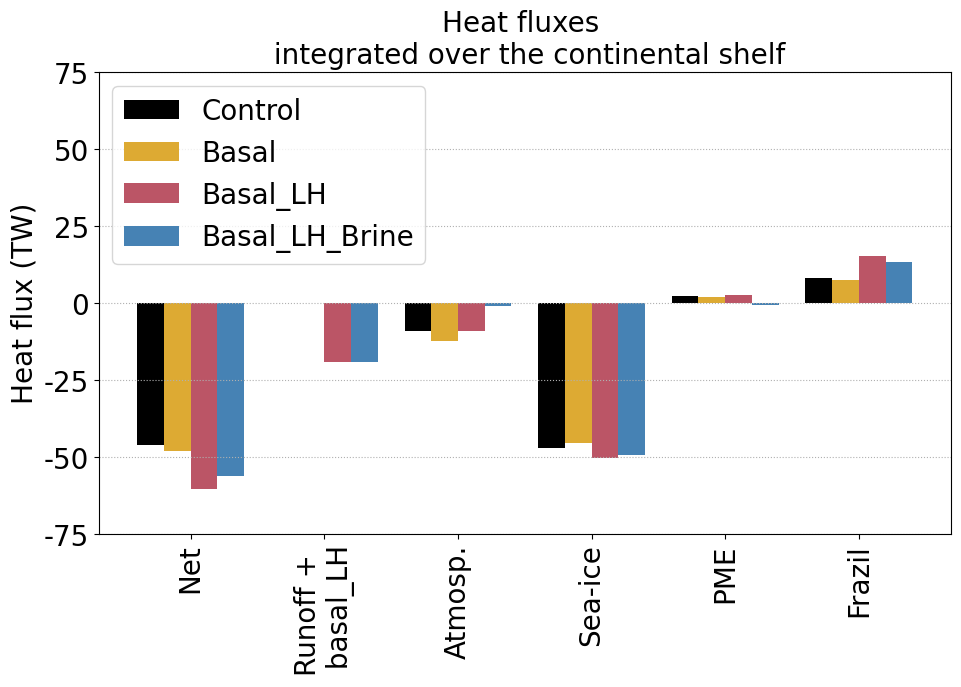

In [23]:
# plot with bars: last year annual avg, horizontally-integrated (over the shelf , depth<1000m only):
fig, ax  = plt.subplots(figsize = (11,6))

pyplot.bar(0.7, HF_runoff_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k', label='Control')
pyplot.bar(0.9, (HF_runoff_annual_hint_shelf_noBG + HF_basalmix_annual_hint_shelf_noBG)*1e-12, width=0.2, color='#DDAA33', label='Basal')
pyplot.bar(1.1, (HF_runoff_annual_hint_shelf_BG + HF_basalmix_annual_hint_shelf_BG)*1e-12, width=0.2, color='#BB5566', label='Basal_LH')
pyplot.bar(1.3, (HF_runoff_annual_hint_shelf_BGB + HF_basalmix_annual_hint_shelf_BGB)*1e-12, width=0.2, color='steelblue', label='Basal_LH_Brine')

plt.legend(fontsize=20)

# coupler - sea-ice
pyplot.bar(1.7, (HF_coupler_annual_hint_shelf_ctrl - HF_mh_annual_hint_shelf_ctrl)*1e-12, width=0.2, color='k', label='Control')
pyplot.bar(1.9, (HF_coupler_annual_hint_shelf_noBG - HF_mh_annual_hint_shelf_noBG)*1e-12, width=0.2, color='#DDAA33', label='Basal')
pyplot.bar(2.1, (HF_coupler_annual_hint_shelf_BG - HF_mh_annual_hint_shelf_BG)*1e-12, width=0.2, color='#BB5566', label='Basal_LH')
pyplot.bar(2.3, (HF_coupler_annual_hint_shelf_BGB - HF_mh_annual_hint_shelf_BGB)*1e-12, width=0.2, color='steelblue', label='Basal_LH_Brine')

pyplot.bar(2.7, HF_mh_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(2.9, HF_mh_annual_hint_shelf_noBG*1e-12, width=0.2, color='#DDAA33')
pyplot.bar(3.1, HF_mh_annual_hint_shelf_BG*1e-12, width=0.2, color='#BB5566')
pyplot.bar(3.3, HF_mh_annual_hint_shelf_BGB*1e-12, width=0.2, color='steelblue')

pyplot.bar(3.7, HF_pme_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(3.9, HF_pme_annual_hint_shelf_noBG*1e-12, width=0.2, color='#DDAA33')
pyplot.bar(4.1, HF_pme_annual_hint_shelf_BG*1e-12, width=0.2, color='#BB5566')
pyplot.bar(4.3, HF_pme_annual_hint_shelf_BGB*1e-12, width=0.2, color='steelblue')

pyplot.bar(4.7, HF_frazil_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(4.9, HF_frazil_annual_hint_shelf_noBG*1e-12, width=0.2, color='#DDAA33')
pyplot.bar(5.1, HF_frazil_annual_hint_shelf_BG*1e-12, width=0.2, color='#BB5566')
pyplot.bar(5.3, HF_frazil_annual_hint_shelf_BGB*1e-12, width=0.2, color='steelblue')

### calculate NET SHF:
HF_net_annual_hint_shelf_ctrl = HF_runoff_annual_hint_shelf_ctrl+HF_coupler_annual_hint_shelf_ctrl+\
    HF_pme_annual_hint_shelf_ctrl+HF_frazil_annual_hint_shelf_ctrl

HF_net_annual_hint_shelf_noBG = HF_runoff_annual_hint_shelf_noBG+HF_coupler_annual_hint_shelf_noBG+\
    HF_pme_annual_hint_shelf_noBG+HF_frazil_annual_hint_shelf_noBG+HF_basalmix_annual_hint_shelf_noBG

HF_net_annual_hint_shelf_BG = HF_runoff_annual_hint_shelf_BG+HF_coupler_annual_hint_shelf_BG+\
    HF_pme_annual_hint_shelf_BG+HF_frazil_annual_hint_shelf_BG+HF_basalmix_annual_hint_shelf_BG

HF_net_annual_hint_shelf_BGB = HF_runoff_annual_hint_shelf_BGB+HF_coupler_annual_hint_shelf_BGB+\
    HF_pme_annual_hint_shelf_BGB+HF_frazil_annual_hint_shelf_BGB+HF_basalmix_annual_hint_shelf_BGB

pyplot.bar(-.3, HF_net_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(-.1, HF_net_annual_hint_shelf_noBG*1e-12, width=0.2, color='#DDAA33')
pyplot.bar(0.1, HF_net_annual_hint_shelf_BG*1e-12, width=0.2, color='#BB5566')
pyplot.bar(.3, HF_net_annual_hint_shelf_BGB*1e-12, width=0.2, color='steelblue')

ax.set_xticks(np.arange(0,6),('Net','Runoff + \n basal_LH','Atmosp.','Sea-ice','PME','Frazil'), rotation=90,fontsize=20) 
ax.set_ylabel('Heat flux (TW)',fontsize=20)
plt.title('Heat fluxes \n integrated over the continental shelf',fontsize=20)
ax.yaxis.grid(True, linestyle=':')

ax.set_ylim(-60,60)
ax.set_yticklabels(np.arange(-75,150,25),fontsize=20)

### Save fig
plt.savefig(figdir+'SHF_components_annual_hint_shelf_yr7-9.png',bbox_inches='tight',dpi=300)

### calculate timeseries

In [24]:
# function to gave integrated on time but no annual average:
def var_hint_shelf(var2d):
    print(var2d.shape)
    # get time length:
    tlen = len(var2d.time)
    for ii in range(0,tlen):
        var_masked = ma.masked_where(ht > 1000, var2d.isel(time=ii)) # masked offshore 1000m isobath
        var_masked_area_tmp = var_masked*area_t # multiply by area
        if ii==0:
             var_hint = np.empty(tlen)
        var_hint_tmp = np.nansum(np.nansum(var_masked_area_tmp, axis=1), axis=0) # sum along x/y axis
        var_hint[ii] = var_hint_tmp
        del var_hint_tmp

    return var_hint

In [25]:
# Basal_gade experiment:

# shelf-only
# HF_runoff_annual_hint_shelf_BG = var_tavg_hint_shelf(sfc_hflux_from_runoff_BG.to_dataarray().squeeze())
# HF_coupler_annual_hint_shelf_BG = var_tavg_hint_shelf(sfc_hflux_coupler_BG.to_dataarray().squeeze())
# HF_pme_annual_hint_shelf_BG = var_tavg_hint_shelf(sfc_hflux_pme_BG.to_dataarray().squeeze())
# HF_frazil_annual_hint_shelf_BG = var_tavg_hint_shelf(frazil_3d_int_z_BG.to_dataarray().squeeze())
# HF_sw_annual_hint_shelf_BG = var_tavg_hint_shelf(swflx_BG.to_dataarray().squeeze())
# HF_lw_annual_hint_shelf_BG = var_tavg_hint_shelf(lw_heat_BG.to_dataarray().squeeze())
# HF_sens_annual_hint_shelf_BG = var_tavg_hint_shelf(sens_heat_BG.to_dataarray().squeeze())
# HF_evap_annual_hint_shelf_BG = var_tavg_hint_shelf(evap_heat_BG.to_dataarray().squeeze())
# HF_fprec_annual_hint_shelf_BG = var_tavg_hint_shelf(fprec_melt_heat_BG.to_dataarray().squeeze())

# # first get vertical sum of basal mix:
# HF_basalmix_annual_vint_BG = temp_basalmix_BG.sum('st_ocean')

# HF_basalmix_annual_hint_shelf_BG = var_tavg_hint_shelf(HF_basalmix_annual_vint_BG.to_dataarray().squeeze())
# HF_mh_annual_hint_shelf_BG = var_tavg_hint_shelf(mhflux_BG)

In [26]:
%%time

### -- all expts, timeseries (should take a long time):

HF_runoff_hint_shelf_ctrl = var_hint_shelf(sfc_hflux_from_runoff_ctrl.to_dataarray().squeeze())
HF_coupler_hint_shelf_ctrl = var_hint_shelf(sfc_hflux_coupler_ctrl.to_dataarray().squeeze())
HF_pme_hint_shelf_ctrl = var_hint_shelf(sfc_hflux_pme_ctrl.to_dataarray().squeeze())
HF_frazil_hint_shelf_ctrl = var_hint_shelf(frazil_3d_int_z_ctrl.to_dataarray().squeeze())
HF_sw_hint_shelf_ctrl = var_hint_shelf(swflx_ctrl.to_dataarray().squeeze())
HF_lw_hint_shelf_ctrl = var_hint_shelf(lw_heat_ctrl.to_dataarray().squeeze())
HF_sens_hint_shelf_ctrl = var_hint_shelf(sens_heat_ctrl.to_dataarray().squeeze())
HF_evap_hint_shelf_ctrl = var_hint_shelf(evap_heat_ctrl.to_dataarray().squeeze())
HF_fprec_hint_shelf_ctrl = var_hint_shelf(fprec_melt_heat_ctrl.to_dataarray().squeeze())

HF_mh_hint_shelf_ctrl = var_tavg_hint_shelf(mhflux_ctrl)

(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
CPU times: user 1min 48s, sys: 10.2 s, total: 1min 58s
Wall time: 3min 10s


In [27]:
HF_runoff_hint_shelf_noBG = var_hint_shelf(sfc_hflux_from_runoff_noBG.to_dataarray().squeeze())
HF_coupler_hint_shelf_noBG = var_hint_shelf(sfc_hflux_coupler_noBG.to_dataarray().squeeze())
HF_pme_hint_shelf_noBG = var_hint_shelf(sfc_hflux_pme_noBG.to_dataarray().squeeze())
HF_frazil_hint_shelf_noBG = var_hint_shelf(frazil_3d_int_z_noBG.to_dataarray().squeeze())
HF_sw_hint_shelf_noBG = var_hint_shelf(swflx_noBG.to_dataarray().squeeze())
HF_lw_hint_shelf_noBG = var_hint_shelf(lw_heat_noBG.to_dataarray().squeeze())
HF_sens_hint_shelf_noBG = var_hint_shelf(sens_heat_noBG.to_dataarray().squeeze())
HF_evap_hint_shelf_noBG = var_hint_shelf(evap_heat_noBG.to_dataarray().squeeze())
HF_fprec_hint_shelf_noBG = var_hint_shelf(fprec_melt_heat_noBG.to_dataarray().squeeze())
HF_mh_hint_shelf_noBG = var_tavg_hint_shelf(mhflux_noBG)

(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)


In [28]:
%%time
HF_basalmix_vint_noBG = temp_basalmix_noBG.sum('st_ocean')
HF_basalmix_hint_shelf_noBG = var_hint_shelf(HF_basalmix_vint_noBG.to_dataarray().squeeze())

(36, 483, 3600)
CPU times: user 9min 14s, sys: 12.7 s, total: 9min 26s
Wall time: 9min 52s


In [29]:
HF_runoff_hint_shelf_BG = var_hint_shelf(sfc_hflux_from_runoff_BG.to_dataarray().squeeze())
HF_coupler_hint_shelf_BG = var_hint_shelf(sfc_hflux_coupler_BG.to_dataarray().squeeze())
HF_pme_hint_shelf_BG = var_hint_shelf(sfc_hflux_pme_BG.to_dataarray().squeeze())
HF_frazil_hint_shelf_BG = var_hint_shelf(frazil_3d_int_z_BG.to_dataarray().squeeze())
HF_sw_hint_shelf_BG = var_hint_shelf(swflx_BG.to_dataarray().squeeze())
HF_lw_hint_shelf_BG = var_hint_shelf(lw_heat_BG.to_dataarray().squeeze())
HF_sens_hint_shelf_BG = var_hint_shelf(sens_heat_BG.to_dataarray().squeeze())
HF_evap_hint_shelf_BG = var_hint_shelf(evap_heat_BG.to_dataarray().squeeze())
HF_fprec_hint_shelf_BG = var_hint_shelf(fprec_melt_heat_BG.to_dataarray().squeeze())
HF_mh_hint_shelf_BG = var_tavg_hint_shelf(mhflux_BG)

HF_basalmix_vint_BG = temp_basalmix_BG.sum('st_ocean')
HF_basalmix_hint_shelf_BG = var_hint_shelf(HF_basalmix_vint_BG.to_dataarray().squeeze())

(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)


In [30]:
HF_runoff_hint_shelf_BGB = var_hint_shelf(sfc_hflux_from_runoff_BGB.to_dataarray().squeeze())
HF_coupler_hint_shelf_BGB = var_hint_shelf(sfc_hflux_coupler_BGB.to_dataarray().squeeze())
HF_pme_hint_shelf_BGB = var_hint_shelf(sfc_hflux_pme_BGB.to_dataarray().squeeze())
HF_frazil_hint_shelf_BGB = var_hint_shelf(frazil_3d_int_z_BGB.to_dataarray().squeeze())
HF_sw_hint_shelf_BGB = var_hint_shelf(swflx_BGB.to_dataarray().squeeze())
HF_lw_hint_shelf_BGB = var_hint_shelf(lw_heat_BGB.to_dataarray().squeeze())
HF_sens_hint_shelf_BGB = var_hint_shelf(sens_heat_BGB.to_dataarray().squeeze())
HF_evap_hint_shelf_BGB = var_hint_shelf(evap_heat_BGB.to_dataarray().squeeze())
HF_fprec_hint_shelf_BGB = var_hint_shelf(fprec_melt_heat_BGB.to_dataarray().squeeze())
HF_mh_hint_shelf_BGB = var_tavg_hint_shelf(mhflux_BGB)

HF_basalmix_vint_BGB = temp_basalmix_BGB.sum('st_ocean')
HF_basalmix_hint_shelf_BGB = var_hint_shelf(HF_basalmix_vint_BGB.to_dataarray().squeeze())

(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)
(36, 483, 3600)


In [31]:
# obtain Sea-ice component:

# mhflux_BGB = sfc_hflux_coupler_BGB.to_dataarray().squeeze() - \
#             (swflx_BGB.to_dataarray().squeeze() +lw_heat_BGB .to_dataarray().squeeze() + \
#              sens_heat_BGB.to_dataarray().squeeze() +evap_heat_BGB.to_dataarray().squeeze() + \
#              fprec_melt_heat_BGB.to_dataarray().squeeze())

HF_mh_hint_shelf_ctrl = HF_coupler_hint_shelf_ctrl - (HF_sw_hint_shelf_ctrl + HF_lw_hint_shelf_ctrl + HF_sens_hint_shelf_ctrl +HF_evap_hint_shelf_ctrl + HF_fprec_hint_shelf_ctrl)
HF_mh_hint_shelf_noBG = HF_coupler_hint_shelf_noBG - (HF_sw_hint_shelf_noBG + HF_lw_hint_shelf_noBG + HF_sens_hint_shelf_noBG +HF_evap_hint_shelf_noBG + HF_fprec_hint_shelf_noBG)
HF_mh_hint_shelf_BG = HF_coupler_hint_shelf_BG - (HF_sw_hint_shelf_BG + HF_lw_hint_shelf_BG + HF_sens_hint_shelf_BG +HF_evap_hint_shelf_BG + HF_fprec_hint_shelf_BG)
HF_mh_hint_shelf_BGB = HF_coupler_hint_shelf_BGB - (HF_sw_hint_shelf_BGB + HF_lw_hint_shelf_BGB + HF_sens_hint_shelf_BGB +HF_evap_hint_shelf_BGB + HF_fprec_hint_shelf_BGB)

### plot timeseries

Text(0, 0.5, 'Frazil')

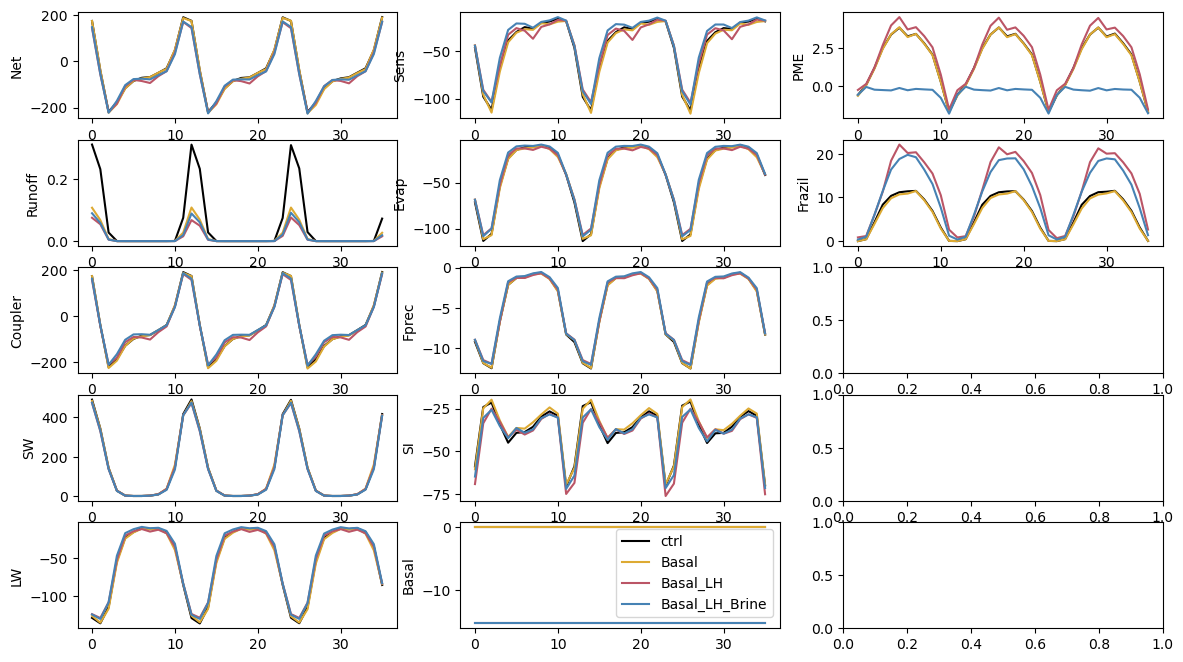

In [32]:
# ### calculate NET SHF:
HF_net_hint_shelf_ctrl = HF_runoff_hint_shelf_ctrl+HF_coupler_hint_shelf_ctrl+\
    HF_pme_hint_shelf_ctrl+HF_frazil_hint_shelf_ctrl

HF_net_hint_shelf_noBG = HF_runoff_hint_shelf_noBG+HF_coupler_hint_shelf_noBG+\
    HF_pme_hint_shelf_noBG+HF_frazil_hint_shelf_noBG+HF_basalmix_hint_shelf_noBG

HF_net_hint_shelf_BG = HF_runoff_hint_shelf_BG[0:118]+HF_coupler_hint_shelf_BG[0:118]+\
    HF_pme_hint_shelf_BG[0:118]+HF_frazil_hint_shelf_BG[0:118]+HF_basalmix_hint_shelf_BG[0:118]

HF_net_hint_shelf_BGB = HF_runoff_hint_shelf_BGB+HF_coupler_hint_shelf_BGB+\
    HF_pme_hint_shelf_BGB+HF_frazil_hint_shelf_BGB+HF_basalmix_hint_shelf_BGB

fig, ax  = plt.subplots(nrows=5,ncols=3, figsize = (14,8))

ax[0,0].plot(HF_net_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[0,0].plot(HF_net_hint_shelf_noBG*1e-12,label='Basal',color='#DDAA33')
ax[0,0].plot(HF_net_hint_shelf_BG*1e-12,label='Basal_LH', color='#BB5566')
ax[0,0].plot(HF_net_hint_shelf_BGB*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[0,0].set_ylabel('Net')

ax[1,0].plot(HF_runoff_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[1,0].plot(HF_runoff_hint_shelf_noBG*1e-12,label='Basal',color='#DDAA33')
ax[1,0].plot(HF_runoff_hint_shelf_BG*1e-12,label='Basal_LH', color='#BB5566')
ax[1,0].plot(HF_runoff_hint_shelf_BGB*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[1,0].set_ylabel('Runoff')

ax[2,0].plot(HF_coupler_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[2,0].plot(HF_coupler_hint_shelf_noBG*1e-12,label='Basal',color='#DDAA33')
ax[2,0].plot(HF_coupler_hint_shelf_BG*1e-12,label='Basal_LH', color='#BB5566')
ax[2,0].plot(HF_coupler_hint_shelf_BGB*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[2,0].set_ylabel('Coupler')

ax[3,0].plot(HF_sw_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[3,0].plot(HF_sw_hint_shelf_noBG*1e-12,label='Basal',color='#DDAA33')
ax[3,0].plot(HF_sw_hint_shelf_BG*1e-12,label='Basal_LH', color='#BB5566')
ax[3,0].plot(HF_sw_hint_shelf_BGB*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[3,0].set_ylabel('SW')

ax[4,0].plot(HF_lw_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[4,0].plot(HF_lw_hint_shelf_noBG*1e-12,label='Basal',color='#DDAA33')
ax[4,0].plot(HF_lw_hint_shelf_BG*1e-12,label='Basal_LH', color='#BB5566')
ax[4,0].plot(HF_lw_hint_shelf_BGB*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[4,0].set_ylabel('LW')

ax[0,1].plot(HF_sens_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[0,1].plot(HF_sens_hint_shelf_noBG*1e-12,label='Basal',color='#DDAA33')
ax[0,1].plot(HF_sens_hint_shelf_BG*1e-12,label='Basal_LH', color='#BB5566')
ax[0,1].plot(HF_sens_hint_shelf_BGB*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[0,1].set_ylabel('Sens')

ax[1,1].plot(HF_evap_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[1,1].plot(HF_evap_hint_shelf_noBG*1e-12,label='Basal',color='#DDAA33')
ax[1,1].plot(HF_evap_hint_shelf_BG*1e-12,label='Basal_LH', color='#BB5566')
ax[1,1].plot(HF_evap_hint_shelf_BGB*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[1,1].set_ylabel('Evap')

ax[2,1].plot(HF_fprec_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[2,1].plot(HF_fprec_hint_shelf_noBG*1e-12,label='Basal',color='#DDAA33')
ax[2,1].plot(HF_fprec_hint_shelf_BG*1e-12,label='Basal_LH', color='#BB5566')
ax[2,1].plot(HF_fprec_hint_shelf_BGB*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[2,1].set_ylabel('Fprec')

ax[3,1].plot(HF_mh_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[3,1].plot(HF_mh_hint_shelf_noBG*1e-12,label='Basal',color='#DDAA33')
ax[3,1].plot(HF_mh_hint_shelf_BG*1e-12,label='Basal_LH', color='#BB5566')
ax[3,1].plot(HF_mh_hint_shelf_BGB*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[3,1].set_ylabel('SI')

ax[4,1].plot(0*HF_basalmix_hint_shelf_BG*1e-12,label='ctrl',color='k')
ax[4,1].plot(HF_basalmix_hint_shelf_noBG*1e-12,label='Basal',color='#DDAA33')
ax[4,1].plot(HF_basalmix_hint_shelf_BG*1e-12,label='Basal_LH', color='#BB5566')
ax[4,1].plot(HF_basalmix_hint_shelf_BGB*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[4,1].set_ylabel('Basal')
ax[4,1].legend()

ax[0,2].plot(HF_pme_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[0,2].plot(HF_pme_hint_shelf_noBG*1e-12,label='Basal',color='#DDAA33')
ax[0,2].plot(HF_pme_hint_shelf_BG*1e-12,label='Basal_LH', color='#BB5566')
ax[0,2].plot(HF_pme_hint_shelf_BGB*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[0,2].set_ylabel('PME')

ax[1,2].plot(HF_frazil_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[1,2].plot(HF_frazil_hint_shelf_noBG*1e-12,label='Basal',color='#DDAA33')
ax[1,2].plot(HF_frazil_hint_shelf_BG*1e-12,label='Basal_LH', color='#BB5566')
ax[1,2].plot(HF_frazil_hint_shelf_BGB*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[1,2].set_ylabel('Frazil')






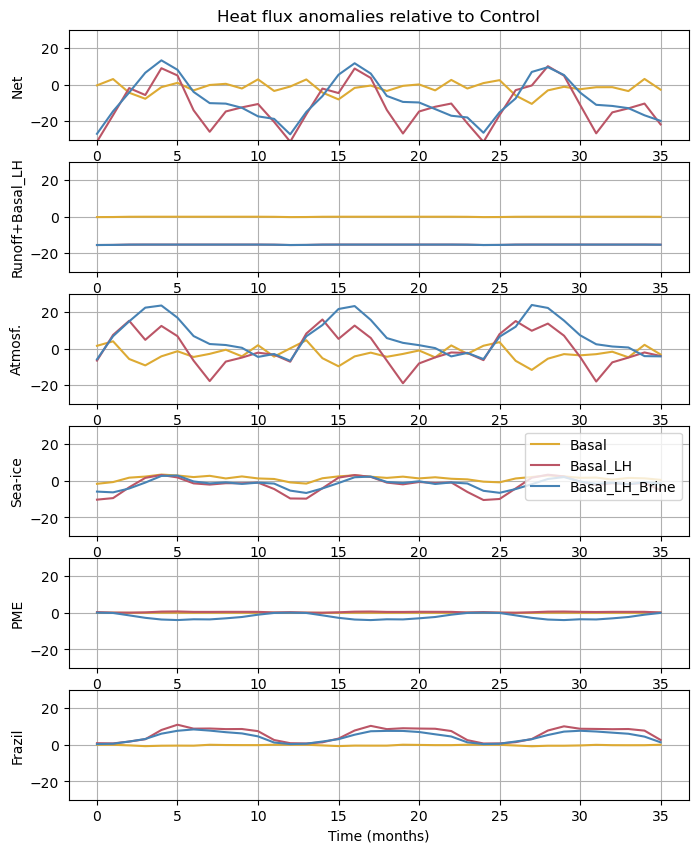

In [33]:
# Figure 1: Coupler condensed
ts = np.divide(np.arange(0,36),1)

fig, ax  = plt.subplots(nrows=6,ncols=1, figsize = (8,10))

ax[0].set_title('Heat flux anomalies relative to Control')

# ax[0].plot(HF_net_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[0].plot(ts,(HF_net_hint_shelf_noBG-HF_net_hint_shelf_ctrl)*1e-12,label='Basal',color='#DDAA33')
ax[0].plot(ts,(HF_net_hint_shelf_BG-HF_net_hint_shelf_ctrl)*1e-12,label='Basal_LH', color='#BB5566')
ax[0].plot(ts,(HF_net_hint_shelf_BGB-HF_net_hint_shelf_ctrl)*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[0].set_ylabel('Net')
ax[0].set_ylim(-30,30)

# ax[1].plot(HF_runoff_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[1].plot(ts,(HF_runoff_hint_shelf_noBG-HF_runoff_hint_shelf_ctrl)*1e-12,label='Basal',color='#DDAA33')
ax[1].plot(ts,(HF_runoff_hint_shelf_BG-HF_runoff_hint_shelf_ctrl+HF_basalmix_hint_shelf_BG)*1e-12,label='Basal_LH', color='#BB5566')
ax[1].plot(ts,(HF_runoff_hint_shelf_BGB-HF_runoff_hint_shelf_ctrl+HF_basalmix_hint_shelf_BGB)*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[1].set_ylabel('Runoff+Basal_LH')
ax[1].set_ylim(-30,30)

# ax[2].plot(HF_coupler_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[2].plot(ts,(HF_coupler_hint_shelf_noBG-(HF_coupler_hint_shelf_ctrl-HF_mh_hint_shelf_ctrl)-HF_mh_hint_shelf_noBG)*1e-12,label='Basal',color='#DDAA33')
ax[2].plot(ts,(HF_coupler_hint_shelf_BG-(HF_coupler_hint_shelf_ctrl-HF_mh_hint_shelf_ctrl)-HF_mh_hint_shelf_BG)*1e-12,label='Basal_LH', color='#BB5566')
ax[2].plot(ts,(HF_coupler_hint_shelf_BGB-(HF_coupler_hint_shelf_ctrl-HF_mh_hint_shelf_ctrl)-HF_mh_hint_shelf_BGB)*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[2].set_ylabel('Atmosf.') # Coupled - sea-ice
ax[2].set_ylim(-30,30)

# ax[3].plot(0*HF_basalmix_hint_shelf_BG*1e-12,label='ctrl',color='k')
ax[3].plot(ts,(HF_mh_hint_shelf_noBG-HF_mh_hint_shelf_ctrl)*1e-12,label='Basal',color='#DDAA33')
ax[3].plot(ts,(HF_mh_hint_shelf_BG-HF_mh_hint_shelf_ctrl)*1e-12,label='Basal_LH', color='#BB5566')
ax[3].plot(ts,(HF_mh_hint_shelf_BGB-HF_mh_hint_shelf_ctrl)*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[3].set_ylabel('Sea-ice')
ax[3].legend()
ax[3].set_ylim(-30,30)

# ax[4].plot(HF_pme_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[4].plot(ts,(HF_pme_hint_shelf_noBG-HF_pme_hint_shelf_ctrl)*1e-12,label='Basal',color='#DDAA33')
ax[4].plot(ts,(HF_pme_hint_shelf_BG-HF_pme_hint_shelf_ctrl)*1e-12,label='Basal_LH', color='#BB5566')
ax[4].plot(ts,(HF_pme_hint_shelf_BGB-HF_pme_hint_shelf_ctrl)*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[4].set_ylabel('PME')
ax[4].set_ylim(-30,30)

# ax[5].plot(HF_frazil_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[5].plot(ts,(HF_frazil_hint_shelf_noBG-HF_frazil_hint_shelf_ctrl)*1e-12,label='Basal',color='#DDAA33')
ax[5].plot(ts,(HF_frazil_hint_shelf_BG-HF_frazil_hint_shelf_ctrl)*1e-12,label='Basal_LH', color='#BB5566')
ax[5].plot(ts,(HF_frazil_hint_shelf_BGB-HF_frazil_hint_shelf_ctrl)*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[5].set_ylabel('Frazil')
ax[5].set_ylim(-30,30)
ax[5].set_xlabel('Time (months)')

for aa in range(0,6):
    ax[aa].grid('on')

plt.savefig(figdir+'SHF_components_annual_hint_shelf_yr7-9_seasonal.png',bbox_inches='tight',dpi=300)



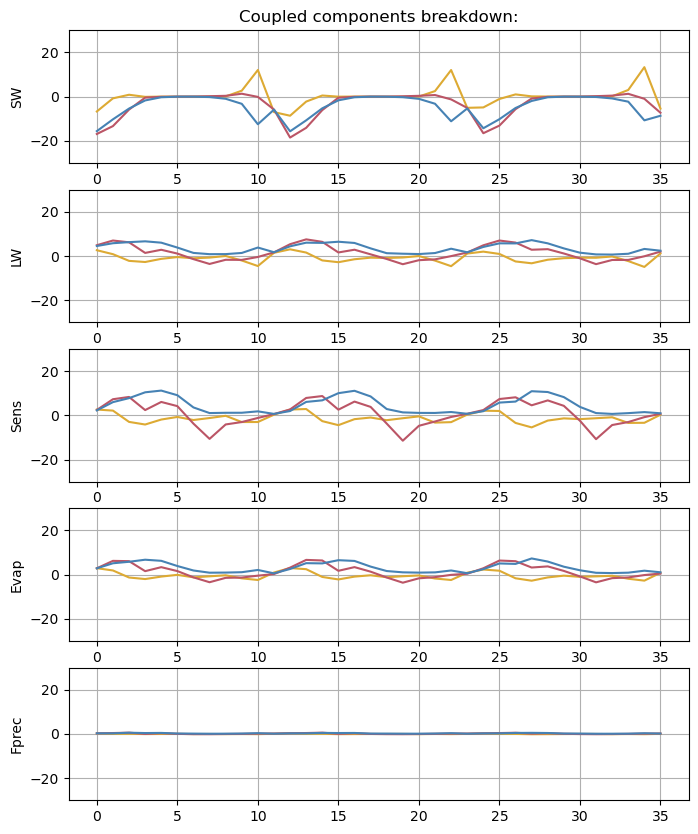

In [34]:
## broking down Coupler components:
fig, ax  = plt.subplots(nrows=5,ncols=1, figsize = (8,10))

ax[0].set_title('Coupled components breakdown:')
# ax[0].plot((HF_sw_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[0].plot((HF_sw_hint_shelf_noBG-HF_sw_hint_shelf_ctrl)*1e-12,label='Basal',color='#DDAA33')
ax[0].plot((HF_sw_hint_shelf_BG-HF_sw_hint_shelf_ctrl)*1e-12,label='Basal_LH', color='#BB5566')
ax[0].plot((HF_sw_hint_shelf_BGB-HF_sw_hint_shelf_ctrl)*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[0].set_ylabel('SW')
ax[0].set_ylim(-30,30)

# ax[1].plot((HF_lw_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[1].plot((HF_lw_hint_shelf_noBG-HF_lw_hint_shelf_ctrl)*1e-12,label='Basal',color='#DDAA33')
ax[1].plot((HF_lw_hint_shelf_BG-HF_lw_hint_shelf_ctrl)*1e-12,label='Basal_LH', color='#BB5566')
ax[1].plot((HF_lw_hint_shelf_BGB-HF_lw_hint_shelf_ctrl)*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[1].set_ylabel('LW')
ax[1].set_ylim(-30,30)

# ax[2].plot((HF_sens_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[2].plot((HF_sens_hint_shelf_noBG-HF_sens_hint_shelf_ctrl)*1e-12,label='Basal',color='#DDAA33')
ax[2].plot((HF_sens_hint_shelf_BG-HF_sens_hint_shelf_ctrl)*1e-12,label='Basal_LH', color='#BB5566')
ax[2].plot((HF_sens_hint_shelf_BGB-HF_sens_hint_shelf_ctrl)*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[2].set_ylabel('Sens')
ax[2].set_ylim(-30,30)

# ax[3].plot((HF_evap_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[3].plot((HF_evap_hint_shelf_noBG-HF_evap_hint_shelf_ctrl)*1e-12,label='Basal',color='#DDAA33')
ax[3].plot((HF_evap_hint_shelf_BG-HF_evap_hint_shelf_ctrl)*1e-12,label='Basal_LH', color='#BB5566')
ax[3].plot((HF_evap_hint_shelf_BGB-HF_evap_hint_shelf_ctrl)*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[3].set_ylabel('Evap')
ax[3].set_ylim(-30,30)

# ax[4].plot((HF_fprec_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[4].plot((HF_fprec_hint_shelf_noBG-HF_fprec_hint_shelf_ctrl)*1e-12,label='Basal',color='#DDAA33')
ax[4].plot((HF_fprec_hint_shelf_BG-HF_fprec_hint_shelf_ctrl)*1e-12,label='Basal_LH', color='#BB5566')
ax[4].plot((HF_fprec_hint_shelf_BGB-HF_fprec_hint_shelf_ctrl)*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[4].set_ylabel('Fprec')
ax[4].set_ylim(-30,30)

# # ax[5].plot((HF_mh_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
# ax[5].plot((HF_mh_hint_shelf_noBG-HF_mh_hint_shelf_ctrl)*1e-12,label='Basal',color='#DDAA33')
# ax[5].plot((HF_mh_hint_shelf_BG-HF_mh_hint_shelf_ctrl)*1e-12,label='Basal_LH', color='#BB5566')
# ax[5].plot((HF_mh_hint_shelf_BGB-HF_mh_hint_shelf_ctrl)*1e-12,label='Basal_LH_Brine', color='steelblue')
# ax[5].set_ylabel('SI')
# ax[5].set_ylim(-30,30)


for aa in range(0,5):
    ax[aa].grid('on')

plt.savefig(figdir+'SHF-coupler_components_annual_hint_shelf_yr7-9_seasonal.png',bbox_inches='tight',dpi=300)



### calculate daily climatology for final plot:

In [35]:
## calculate daily climatology:

def calculate_daily_clim(var):

    var_clim = np.empty((12))

    for ii in np.arange(0,12):
        tmp = var[ii] + var[ii+12] + var[ii+24]
        var_clim[ii] = np.divide(tmp,3)
        
    return var_clim


In [36]:
HF_net_hint_shelf_ctrl_clim = calculate_daily_clim(HF_net_hint_shelf_ctrl)
HF_net_hint_shelf_noBG_clim = calculate_daily_clim(HF_net_hint_shelf_noBG)
HF_net_hint_shelf_BG_clim = calculate_daily_clim(HF_net_hint_shelf_BG)
HF_net_hint_shelf_BGB_clim = calculate_daily_clim(HF_net_hint_shelf_BGB)


In [37]:
HF_runoff_hint_shelf_ctrl_clim = calculate_daily_clim(HF_runoff_hint_shelf_ctrl)
HF_runoff_hint_shelf_noBG_clim = calculate_daily_clim(HF_runoff_hint_shelf_noBG)
HF_runoff_hint_shelf_BG_clim = calculate_daily_clim(HF_runoff_hint_shelf_BG)
HF_runoff_hint_shelf_BGB_clim = calculate_daily_clim(HF_runoff_hint_shelf_BGB)


In [38]:
HF_basalmix_hint_shelf_noBG_clim = calculate_daily_clim(HF_basalmix_hint_shelf_noBG)
HF_basalmix_hint_shelf_BG_clim = calculate_daily_clim(HF_basalmix_hint_shelf_BG)
HF_basalmix_hint_shelf_BGB_clim = calculate_daily_clim(HF_basalmix_hint_shelf_BGB)


In [39]:
HF_coupler_hint_shelf_ctrl_clim = calculate_daily_clim(HF_coupler_hint_shelf_ctrl)
HF_coupler_hint_shelf_noBG_clim = calculate_daily_clim(HF_coupler_hint_shelf_noBG)
HF_coupler_hint_shelf_BG_clim = calculate_daily_clim(HF_coupler_hint_shelf_BG)
HF_coupler_hint_shelf_BGB_clim = calculate_daily_clim(HF_coupler_hint_shelf_BGB)


In [40]:
HF_mh_hint_shelf_ctrl_clim = calculate_daily_clim(HF_mh_hint_shelf_ctrl)
HF_mh_hint_shelf_noBG_clim = calculate_daily_clim(HF_mh_hint_shelf_noBG)
HF_mh_hint_shelf_BG_clim = calculate_daily_clim(HF_mh_hint_shelf_BG)
HF_mh_hint_shelf_BGB_clim = calculate_daily_clim(HF_mh_hint_shelf_BGB)


In [41]:
HF_pme_hint_shelf_ctrl_clim = calculate_daily_clim(HF_pme_hint_shelf_ctrl)
HF_pme_hint_shelf_noBG_clim = calculate_daily_clim(HF_pme_hint_shelf_noBG)
HF_pme_hint_shelf_BG_clim = calculate_daily_clim(HF_pme_hint_shelf_BG)
HF_pme_hint_shelf_BGB_clim = calculate_daily_clim(HF_pme_hint_shelf_BGB)


In [42]:
HF_frazil_hint_shelf_ctrl_clim = calculate_daily_clim(HF_frazil_hint_shelf_ctrl)
HF_frazil_hint_shelf_noBG_clim = calculate_daily_clim(HF_frazil_hint_shelf_noBG)
HF_frazil_hint_shelf_BG_clim = calculate_daily_clim(HF_frazil_hint_shelf_BG)
HF_frazil_hint_shelf_BGB_clim = calculate_daily_clim(HF_frazil_hint_shelf_BGB)


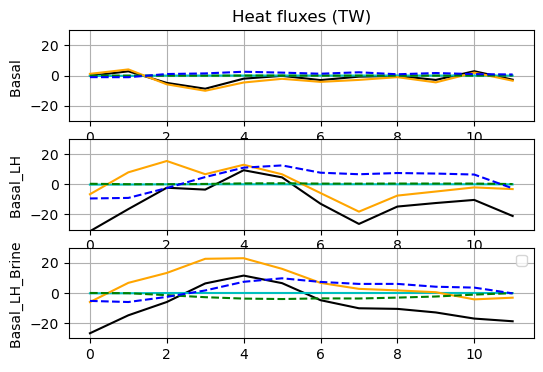

In [43]:
fig, ax  = plt.subplots(nrows=3,ncols=1, figsize = (6,4))
ax[0].set_title('Heat fluxes (TW)')
ax[0].plot((HF_net_hint_shelf_noBG_clim-HF_net_hint_shelf_ctrl_clim)*1e-12
         ,label='Net',color='k')
ax[0].plot((HF_runoff_hint_shelf_noBG_clim-HF_runoff_hint_shelf_ctrl_clim)*1e-12
         ,'-',label='Runoff + basal',color='c')
ax[0].plot(((HF_coupler_hint_shelf_noBG_clim-HF_mh_hint_shelf_noBG_clim)-
           (HF_coupler_hint_shelf_ctrl_clim-HF_mh_hint_shelf_ctrl_clim))*1e-12
         ,'-',label='Atmosphere',color='orange')
ax[0].plot((HF_pme_hint_shelf_noBG_clim-HF_pme_hint_shelf_ctrl_clim)*1e-12
          ,'--',label='PME',color='g')
ax[0].plot(((HF_mh_hint_shelf_noBG_clim+HF_frazil_hint_shelf_noBG_clim)-
           (HF_mh_hint_shelf_ctrl_clim+HF_frazil_hint_shelf_ctrl_clim))*1e-12
          ,'--',label='Sea ice + frazil',color='b')
plt.legend(loc='best')

ax[1].plot((HF_net_hint_shelf_BG_clim-HF_net_hint_shelf_ctrl_clim)*1e-12
         ,label='Net',color='k')
ax[1].plot((HF_runoff_hint_shelf_BG_clim-HF_runoff_hint_shelf_ctrl_clim)*1e-12
         ,'-',label='Runoff + basal',color='c')
ax[1].plot(((HF_coupler_hint_shelf_BG_clim-HF_mh_hint_shelf_BG_clim)-
           (HF_coupler_hint_shelf_ctrl_clim-HF_mh_hint_shelf_ctrl_clim))*1e-12
         ,'-',label='Atmosphere',color='orange')
ax[1].plot((HF_pme_hint_shelf_BG_clim-HF_pme_hint_shelf_ctrl_clim)*1e-12
          ,'--',label='PME',color='g')
ax[1].plot(((HF_mh_hint_shelf_BG_clim+HF_frazil_hint_shelf_BG_clim)-
           (HF_mh_hint_shelf_ctrl_clim+HF_frazil_hint_shelf_ctrl_clim))*1e-12
          ,'--',label='Sea ice + frazil',color='b')

ax[2].plot((HF_net_hint_shelf_BGB_clim-HF_net_hint_shelf_ctrl_clim)*1e-12
         ,label='Net',color='k')
ax[2].plot((HF_runoff_hint_shelf_BGB_clim-HF_runoff_hint_shelf_ctrl_clim)*1e-12
         ,'-',label='Runoff + basal',color='c')
ax[2].plot(((HF_coupler_hint_shelf_BGB_clim-HF_mh_hint_shelf_BGB_clim)-
           (HF_coupler_hint_shelf_ctrl_clim-HF_mh_hint_shelf_ctrl_clim))*1e-12
         ,'-',label='Atmosphere',color='orange')
ax[2].plot((HF_pme_hint_shelf_BGB_clim-HF_pme_hint_shelf_ctrl_clim)*1e-12
          ,'--',label='PME',color='g')
ax[2].plot(((HF_mh_hint_shelf_BGB_clim+HF_frazil_hint_shelf_BGB_clim)-
           (HF_mh_hint_shelf_ctrl_clim+HF_frazil_hint_shelf_ctrl_clim))*1e-12
          ,'--',label='Sea ice + frazil',color='b')


ax[0].set_ylim(-30,30)
ax[1].set_ylim(-30,30)
ax[2].set_ylim(-30,30)
ax[0].set_ylabel('Basal ')           
ax[1].set_ylabel('Basal_LH ')           
ax[2].set_ylabel('Basal_LH_Brine ')     
ax[0].grid('on')
ax[1].grid('on')
ax[2].grid('on')

#### Final plot

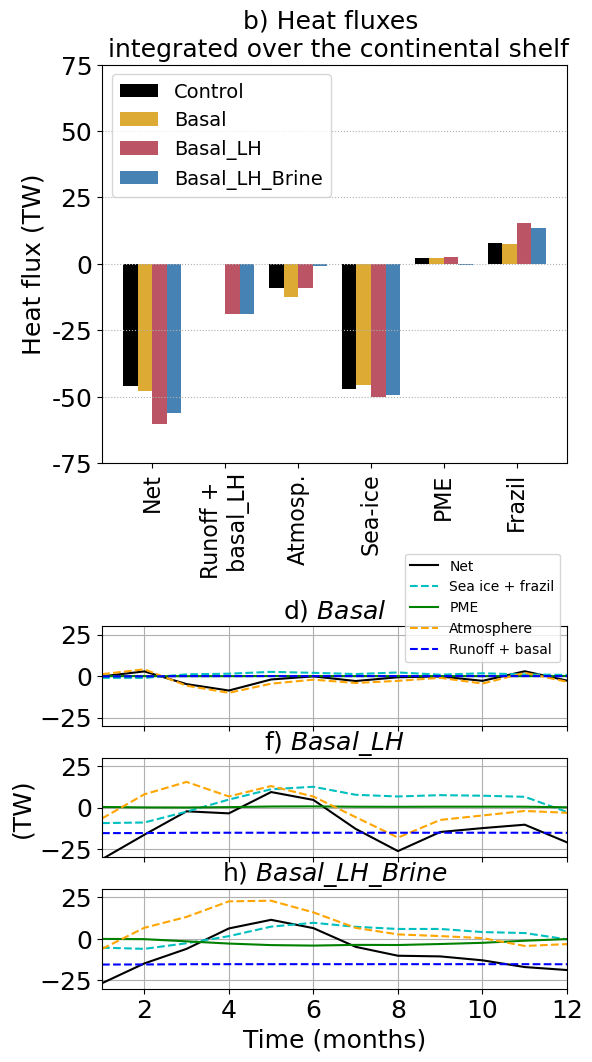

In [48]:
# plot with bars: last year annual avg, horizontally-integrated (over the shelf , depth<1000m only):
fig, ax  = plt.subplots(nrows=5, figsize = (6,12), gridspec_kw={'height_ratios': [1, 0.25, 0.25, 0.25, 0.25]})

ax[0].bar(0.7, HF_runoff_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k', label='Control')
ax[0].bar(0.9, (HF_runoff_annual_hint_shelf_noBG + HF_basalmix_annual_hint_shelf_noBG)*1e-12, width=0.2, color='#DDAA33', label='Basal')
ax[0].bar(1.1, (HF_runoff_annual_hint_shelf_BG + HF_basalmix_annual_hint_shelf_BG)*1e-12, width=0.2, color='#BB5566', label='Basal_LH')
ax[0].bar(1.3, (HF_runoff_annual_hint_shelf_BGB + HF_basalmix_annual_hint_shelf_BGB)*1e-12, width=0.2, color='steelblue', label='Basal_LH_Brine')

ax[0].legend(fontsize=14,loc='upper left')

# coupler - sea-ice
ax[0].bar(1.7, (HF_coupler_annual_hint_shelf_ctrl - HF_mh_annual_hint_shelf_ctrl)*1e-12, width=0.2, color='k', label='Control')
ax[0].bar(1.9, (HF_coupler_annual_hint_shelf_noBG - HF_mh_annual_hint_shelf_noBG)*1e-12, width=0.2, color='#DDAA33', label='Basal')
ax[0].bar(2.1, (HF_coupler_annual_hint_shelf_BG - HF_mh_annual_hint_shelf_BG)*1e-12, width=0.2, color='#BB5566', label='Basal_LH')
ax[0].bar(2.3, (HF_coupler_annual_hint_shelf_BGB - HF_mh_annual_hint_shelf_BGB)*1e-12, width=0.2, color='steelblue', label='Basal_LH_Brine')

ax[0].bar(2.7, HF_mh_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
ax[0].bar(2.9, HF_mh_annual_hint_shelf_noBG*1e-12, width=0.2, color='#DDAA33')
ax[0].bar(3.1, HF_mh_annual_hint_shelf_BG*1e-12, width=0.2, color='#BB5566')
ax[0].bar(3.3, HF_mh_annual_hint_shelf_BGB*1e-12, width=0.2, color='steelblue')

ax[0].bar(3.7, HF_pme_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
ax[0].bar(3.9, HF_pme_annual_hint_shelf_noBG*1e-12, width=0.2, color='#DDAA33')
ax[0].bar(4.1, HF_pme_annual_hint_shelf_BG*1e-12, width=0.2, color='#BB5566')
ax[0].bar(4.3, HF_pme_annual_hint_shelf_BGB*1e-12, width=0.2, color='steelblue')

ax[0].bar(4.7, HF_frazil_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
ax[0].bar(4.9, HF_frazil_annual_hint_shelf_noBG*1e-12, width=0.2, color='#DDAA33')
ax[0].bar(5.1, HF_frazil_annual_hint_shelf_BG*1e-12, width=0.2, color='#BB5566')
ax[0].bar(5.3, HF_frazil_annual_hint_shelf_BGB*1e-12, width=0.2, color='steelblue')

### calculate NET SHF:
HF_net_annual_hint_shelf_ctrl = HF_runoff_annual_hint_shelf_ctrl+HF_coupler_annual_hint_shelf_ctrl+\
    HF_pme_annual_hint_shelf_ctrl+HF_frazil_annual_hint_shelf_ctrl

HF_net_annual_hint_shelf_noBG = HF_runoff_annual_hint_shelf_noBG+HF_coupler_annual_hint_shelf_noBG+\
    HF_pme_annual_hint_shelf_noBG+HF_frazil_annual_hint_shelf_noBG+HF_basalmix_annual_hint_shelf_noBG

HF_net_annual_hint_shelf_BG = HF_runoff_annual_hint_shelf_BG+HF_coupler_annual_hint_shelf_BG+\
    HF_pme_annual_hint_shelf_BG+HF_frazil_annual_hint_shelf_BG+HF_basalmix_annual_hint_shelf_BG

HF_net_annual_hint_shelf_BGB = HF_runoff_annual_hint_shelf_BGB+HF_coupler_annual_hint_shelf_BGB+\
    HF_pme_annual_hint_shelf_BGB+HF_frazil_annual_hint_shelf_BGB+HF_basalmix_annual_hint_shelf_BGB

ax[0].bar(-.3, HF_net_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
ax[0].bar(-.1, HF_net_annual_hint_shelf_noBG*1e-12, width=0.2, color='#DDAA33')
ax[0].bar(0.1, HF_net_annual_hint_shelf_BG*1e-12, width=0.2, color='#BB5566')
ax[0].bar(.3, HF_net_annual_hint_shelf_BGB*1e-12, width=0.2, color='steelblue')

ax[0].set_xticks(np.arange(0,6),('Net','Runoff + \n basal_LH','Atmosp.','Sea-ice','PME','Frazil'), rotation=90,fontsize=16) 
ax[0].set_ylabel('Heat flux (TW)',fontsize=18)
ax[0].set_title('b) Heat fluxes \n integrated over the continental shelf',fontsize=18)
ax[0].yaxis.grid(True, linestyle=':')

ax[0].set_ylim(-60,60)
ax[0].set_yticklabels(np.arange(-75,150,25),fontsize=18)

ax[1].axis('off')

# ax[2].set_title('Heat fluxes (TW)',fontsize=18)
ax[2].plot(np.arange(1,13),(HF_net_hint_shelf_noBG_clim-HF_net_hint_shelf_ctrl_clim)*1e-12
         ,label='Net',color='k')
ax[2].plot(np.arange(1,13),((HF_mh_hint_shelf_noBG_clim+HF_frazil_hint_shelf_noBG_clim)-
           (HF_mh_hint_shelf_ctrl_clim+HF_frazil_hint_shelf_ctrl_clim))*1e-12
          ,'--',label='Sea ice + frazil',color='c')
ax[2].plot(np.arange(1,13),(HF_pme_hint_shelf_noBG_clim-HF_pme_hint_shelf_ctrl_clim)*1e-12
          ,'-',label='PME',color='g')
ax[2].plot(np.arange(1,13),((HF_coupler_hint_shelf_noBG_clim-HF_mh_hint_shelf_noBG_clim)-
           (HF_coupler_hint_shelf_ctrl_clim-HF_mh_hint_shelf_ctrl_clim))*1e-12
         ,'--',label='Atmosphere',color='orange')
ax[2].plot(np.arange(1,13),(HF_runoff_hint_shelf_noBG_clim+HF_basalmix_hint_shelf_noBG_clim-HF_runoff_hint_shelf_ctrl_clim)*1e-12
         ,'--',label='Runoff + basal',color='b')


ax[3].plot(np.arange(1,13),(HF_net_hint_shelf_BG_clim-HF_net_hint_shelf_ctrl_clim)*1e-12
         ,label='Net',color='k')
ax[3].plot(np.arange(1,13),((HF_mh_hint_shelf_BG_clim+HF_frazil_hint_shelf_BG_clim)-
           (HF_mh_hint_shelf_ctrl_clim+HF_frazil_hint_shelf_ctrl_clim))*1e-12
          ,'--',label='Sea ice + frazil',color='c')
ax[3].plot(np.arange(1,13),(HF_pme_hint_shelf_BG_clim-HF_pme_hint_shelf_ctrl_clim)*1e-12
          ,'-',label='PME',color='g')
ax[3].plot(np.arange(1,13),((HF_coupler_hint_shelf_BG_clim-HF_mh_hint_shelf_BG_clim)-
           (HF_coupler_hint_shelf_ctrl_clim-HF_mh_hint_shelf_ctrl_clim))*1e-12
         ,'--',label='Atmosphere',color='orange')
ax[3].plot(np.arange(1,13),(HF_runoff_hint_shelf_BG_clim+HF_basalmix_hint_shelf_BG_clim-HF_runoff_hint_shelf_ctrl_clim)*1e-12
         ,'--',label='Runoff + basal',color='b')

ax[4].plot(np.arange(1,13),(HF_net_hint_shelf_BGB_clim-HF_net_hint_shelf_ctrl_clim)*1e-12
         ,label='Net',color='k')
ax[4].plot(np.arange(1,13),((HF_mh_hint_shelf_BGB_clim+HF_frazil_hint_shelf_BGB_clim)-
           (HF_mh_hint_shelf_ctrl_clim+HF_frazil_hint_shelf_ctrl_clim))*1e-12
          ,'--',label='Sea ice + frazil',color='c')
ax[4].plot(np.arange(1,13),(HF_pme_hint_shelf_BGB_clim-HF_pme_hint_shelf_ctrl_clim)*1e-12
          ,'-',label='PME',color='g')
ax[4].plot(np.arange(1,13),((HF_coupler_hint_shelf_BGB_clim-HF_mh_hint_shelf_BGB_clim)-
           (HF_coupler_hint_shelf_ctrl_clim-HF_mh_hint_shelf_ctrl_clim))*1e-12
         ,'--',label='Atmosphere',color='orange')
ax[4].plot(np.arange(1,13),(HF_runoff_hint_shelf_BGB_clim+HF_basalmix_hint_shelf_BGB_clim-HF_runoff_hint_shelf_ctrl_clim)*1e-12
         ,'--',label='Runoff + basal',color='b')
ax[4].set_xlabel('Time (months)',fontsize=18)
ax[2].set_xticklabels('')
ax[3].set_xticklabels('')

# ax[2].legend(loc='upper right')
ax[2].legend(loc='upper right', bbox_to_anchor=(1.0, 1.8), fontsize=10)

ax[2].tick_params(axis='both', labelsize=18)
ax[3].tick_params(axis='both', labelsize=18)
ax[4].tick_params(axis='both', labelsize=18)

ax[2].set_ylim(-30,30)
ax[3].set_ylim(-30,30)
ax[4].set_ylim(-30,30)
ax[2].set_xlim(1,12)
ax[3].set_xlim(1,12)
ax[4].set_xlim(1,12)
ax[2].set_title('d) $Basal$',fontsize=18)
ax[3].set_title('f) $Basal{\_}LH$',fontsize=18)
ax[4].set_title('h) $Basal{\_}LH{\_}Brine$',fontsize=18)   
ax[2].grid('on')
ax[3].grid('on')
ax[4].grid('on')
ax[3].set_ylabel('(TW)',fontsize=18)


### Save fig
plt.savefig(figdir+'SHF_components_annual_hint_shelf_yr7-9_final.png',bbox_inches='tight',dpi=300)

In [53]:
print(figdir+'SHF_components_annual_hint_shelf_yr7-9_final.png')

/g/data/e14/fbd581/basal_mom5-collaborative-project/figures/SHF_components_annual_hint_shelf_yr7-9_final.png


### old plots

NameError: name 'HF_runoff_annual_hint_shelf_ICB' is not defined

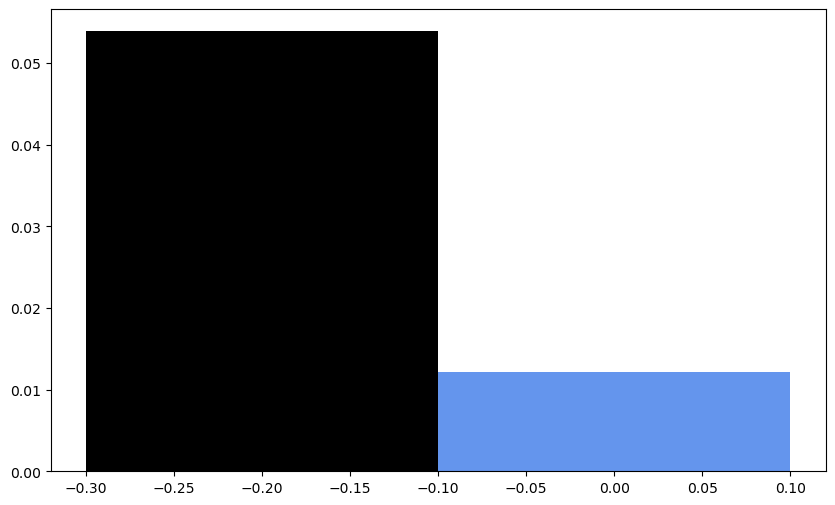

In [46]:
# plot with bars: last year annual avg, horizontally-integrated (over the shelf , depth<1000m only):
fig, ax  = plt.subplots(figsize = (10,6))

pyplot.bar(-.2, HF_runoff_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k', label='Control')
pyplot.bar(0, HF_runoff_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue', label='Basal')
pyplot.bar(0.2, HF_runoff_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange', label='ICB')

plt.legend()

pyplot.bar(.8, HF_coupler_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k', label='Control')
pyplot.bar(1, HF_coupler_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue', label='Basal')
pyplot.bar(1.2, HF_coupler_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange', label='ICB')

pyplot.bar(1.8, HF_sw_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(2, HF_sw_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(2.2, HF_sw_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')

pyplot.bar(2.8, HF_lw_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(3, HF_lw_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(3.2, HF_lw_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')

pyplot.bar(3.8, HF_sens_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(4, HF_sens_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(4.2, HF_sens_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')

pyplot.bar(4.8, HF_evap_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(5, HF_evap_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(5.2, HF_evap_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')

pyplot.bar(5.8, HF_fprec_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(6, HF_fprec_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(6.2, HF_fprec_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')

pyplot.bar(6.8, HF_mh_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(7, HF_mh_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(7.2, HF_mh_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')

pyplot.bar(8, HF_basalmix_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(8.2, HF_basalmix_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')

pyplot.bar(9, HF_icbmix_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(9.2, HF_icbmix_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')

pyplot.bar(9.8, HF_pme_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(10, HF_pme_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(10.2, HF_pme_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')

pyplot.bar(10.8, HF_frazil_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(11, HF_frazil_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(11.2, HF_frazil_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')

# calculate NET SHF:
HF_net_annual_hint_shelf_ctrl = HF_runoff_annual_hint_shelf_ctrl+HF_coupler_annual_hint_shelf_ctrl+\
    HF_pme_annual_hint_shelf_ctrl+HF_frazil_annual_hint_shelf_ctrl

HF_net_annual_hint_shelf_BG = HF_runoff_annual_hint_shelf_BG+HF_coupler_annual_hint_shelf_BG+\
    HF_pme_annual_hint_shelf_BG+HF_frazil_annual_hint_shelf_BG+HF_basalmix_annual_hint_shelf_BG+HF_icbmix_annual_hint_shelf_BG

HF_net_annual_hint_shelf_ICB = HF_runoff_annual_hint_shelf_ICB+HF_coupler_annual_hint_shelf_ICB+\
    HF_pme_annual_hint_shelf_ICB+HF_frazil_annual_hint_shelf_ICB+HF_basalmix_annual_hint_shelf_ICB+HF_icbmix_annual_hint_shelf_ICB

pyplot.bar(11.8, HF_net_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(12, HF_net_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(12.2, HF_net_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')

ax.set_xticks(np.arange(0,13),('Runoff','Coupler','SW','LW','Sens','Evap','Fprec','MH','Basal \n mix','ICB \n mix','PME','Frazil','Net'))
# ax.set_xticks(np.arange(1,6),('Runoff','Basal mix','ICB mix','PME','Frazil'))#,'MH'))
ax.set_xlabel('Surface flux components')
ax.set_ylabel('Heat flux (TW)')

plt.title('Shelf')

### Save fig
plt.savefig(figdir+'SHF_components_annual_hint_shelf_yr10.png')

In [ ]:
# plot with bars: last year annual avg, horizontally-integrated (over the shelf , depth<1000m only):
fig, ax  = plt.subplots(figsize = (10,6))

pyplot.bar(-.15, HF_runoff_annual_hint_shelf_ctrl*1e-12, width=0.15, color='k', label='Control')
pyplot.bar(0, HF_runoff_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33', label='Basal')
pyplot.bar(0.15, HF_runoff_annual_hint_shelf_BG*1e-12, width=0.15, color='#BB5566', label='BasalGade')
pyplot.bar(0.3, HF_runoff_annual_hint_shelf_BGB*1e-12, width=0.15, color='steelblue', label='BasalGadeBrine')

plt.legend()

pyplot.bar(.85, HF_coupler_annual_hint_shelf_ctrl*1e-12, width=0.15, color='k', label='Control')
pyplot.bar(1, HF_coupler_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33', label='Basal')
pyplot.bar(1.15, HF_coupler_annual_hint_shelf_BG*1e-12, width=0.15, color='#BB5566', label='BasalGade')
pyplot.bar(1.3, HF_coupler_annual_hint_shelf_BGB*1e-12, width=0.15, color='steelblue', label='BasalGadeBrine')

pyplot.bar(1.85, HF_sw_annual_hint_shelf_ctrl*1e-12, width=0.15, color='k')
pyplot.bar(2, HF_sw_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33')
pyplot.bar(2.15, HF_sw_annual_hint_shelf_BG*1e-12, width=0.15, color='#BB5566')
pyplot.bar(2.3, HF_sw_annual_hint_shelf_BGB*1e-12, width=0.15, color='steelblue')

pyplot.bar(2.85, HF_lw_annual_hint_shelf_ctrl*1e-12, width=0.15, color='k')
pyplot.bar(3., HF_lw_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33')
pyplot.bar(3.15, HF_lw_annual_hint_shelf_BG*1e-12, width=0.15, color='#BB5566')
pyplot.bar(3.3, HF_lw_annual_hint_shelf_BGB*1e-12, width=0.15, color='steelblue')

pyplot.bar(3.85, HF_sens_annual_hint_shelf_ctrl*1e-12, width=0.15, color='k')
pyplot.bar(4., HF_sens_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33')
pyplot.bar(4.15, HF_sens_annual_hint_shelf_BG*1e-12, width=0.15, color='#BB5566')
pyplot.bar(4.3, HF_sens_annual_hint_shelf_BGB*1e-12, width=0.15, color='steelblue')

pyplot.bar(4.85, HF_evap_annual_hint_shelf_ctrl*1e-12, width=0.15, color='k')
pyplot.bar(5., HF_evap_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33')
pyplot.bar(5.15, HF_evap_annual_hint_shelf_BG*1e-12, width=0.15, color='#BB5566')
pyplot.bar(5.3, HF_evap_annual_hint_shelf_BGB*1e-12, width=0.15, color='steelblue')

pyplot.bar(5.85, HF_fprec_annual_hint_shelf_ctrl*1e-12, width=0.15, color='k')
pyplot.bar(6., HF_fprec_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33')
pyplot.bar(6.15, HF_fprec_annual_hint_shelf_BG*1e-12, width=0.15, color='#BB5566')
pyplot.bar(6.3, HF_fprec_annual_hint_shelf_BGB*1e-12, width=0.15, color='steelblue')

pyplot.bar(6.85, HF_mh_annual_hint_shelf_ctrl*1e-12, width=0.15, color='k')
pyplot.bar(7, HF_mh_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33')
pyplot.bar(7.15, HF_mh_annual_hint_shelf_BG*1e-12, width=0.15, color='#BB5566')
pyplot.bar(7.3, HF_mh_annual_hint_shelf_BGB*1e-12, width=0.15, color='steelblue')

pyplot.bar(8, HF_basalmix_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33')
pyplot.bar(8.15, HF_basalmix_annual_hint_shelf_BG*1e-12, width=0.15, color='#BB5566')
pyplot.bar(8.3, HF_basalmix_annual_hint_shelf_BGB*1e-12, width=0.15, color='steelblue')

# pyplot.bar(9, HF_icbmix_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33')
# pyplot.bar(9.15, HF_icbmix_annual_hint_shelf_BG*1e-12, width=0.15, color='#BB5566')

pyplot.bar(9.85, HF_pme_annual_hint_shelf_ctrl*1e-12, width=0.15, color='k')
pyplot.bar(10, HF_pme_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33')
pyplot.bar(10.15, HF_pme_annual_hint_shelf_BG*1e-12, width=0.15, color='#BB5566')
pyplot.bar(10.3, HF_pme_annual_hint_shelf_BGB*1e-12, width=0.15, color='steelblue')

pyplot.bar(10.85, HF_frazil_annual_hint_shelf_ctrl*1e-12, width=0.15, color='k')
pyplot.bar(11, HF_frazil_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33')
pyplot.bar(11.15, HF_frazil_annual_hint_shelf_BG*1e-12, width=0.15, color='#BB5566')
pyplot.bar(11.3, HF_frazil_annual_hint_shelf_BGB*1e-12, width=0.15, color='steelblue')

### calculate NET SHF:
HF_net_annual_hint_shelf_ctrl = HF_runoff_annual_hint_shelf_ctrl+HF_coupler_annual_hint_shelf_ctrl+\
    HF_pme_annual_hint_shelf_ctrl+HF_frazil_annual_hint_shelf_ctrl

HF_net_annual_hint_shelf_noBG = HF_runoff_annual_hint_shelf_noBG+HF_coupler_annual_hint_shelf_noBG+\
    HF_pme_annual_hint_shelf_noBG+HF_frazil_annual_hint_shelf_noBG+HF_basalmix_annual_hint_shelf_noBG#+HF_icbmix_annual_hint_shelf_noBG

HF_net_annual_hint_shelf_BG = HF_runoff_annual_hint_shelf_BG+HF_coupler_annual_hint_shelf_BG+\
    HF_pme_annual_hint_shelf_BG+HF_frazil_annual_hint_shelf_BG+HF_basalmix_annual_hint_shelf_BG#+HF_icbmix_annual_hint_shelf_BG

HF_net_annual_hint_shelf_BGB = HF_runoff_annual_hint_shelf_BGB+HF_coupler_annual_hint_shelf_BGB+\
    HF_pme_annual_hint_shelf_BGB+HF_frazil_annual_hint_shelf_BGB+HF_basalmix_annual_hint_shelf_BGB

pyplot.bar(11.85, HF_net_annual_hint_shelf_ctrl*1e-12, width=0.15, color='k')
pyplot.bar(12, HF_net_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33')
pyplot.bar(12.15, HF_net_annual_hint_shelf_BG*1e-12, width=0.15, color='#BB5566')
pyplot.bar(12.3, HF_net_annual_hint_shelf_BGB*1e-12, width=0.15, color='steelblue')

ax.set_xticks(np.arange(0,13),('Runoff','Coupler','SW','LW','Sens','Evap','Fprec','MH','Basal \n mix','ICB \n mix','PME','Frazil','Net'))
# ax.set_xticks(np.arange(1,6),('Runoff','Basal mix','ICB mix','PME','Frazil'))#,'MH'))
ax.set_xlabel('Surface flux components')
ax.set_ylabel('Heat flux (TW)')

plt.title('Shelf')

### Save fig
plt.savefig(figdir+'SHF_components_annual_hint_shelf_yr8-10.png')

In [ ]:
# print(HF_net_annual_hint_shelf_ctrl*1e-12, HF_net_annual_hint_shelf_noBG*1e-12, HF_net_annual_hint_shelf_BG*1e-12, HF_net_annual_hint_shelf_ICB*1e-12)

In [ ]:
print(' --- NET ---')
print('Control = ', HF_net_annual_hint_shelf_ctrl*1e-12)
print('BG = ', HF_net_annual_hint_shelf_BG*1e-12)
print('ICB = ', HF_net_annual_hint_shelf_ICB*1e-12)
print('noBG = ', HF_net_annual_hint_shelf_noBG*1e-12)
print('BGB = ', HF_net_annual_hint_shelf_BGB*1e-12)

print(' --- RUNOFF ---')
print('Control = ', HF_runoff_annual_hint_shelf_ctrl*1e-12)
print('BG = ', HF_runoff_annual_hint_shelf_BG*1e-12)
print('ICB = ', HF_runoff_annual_hint_shelf_ICB*1e-12)
print('noBG = ', HF_runoff_annual_hint_shelf_noBG*1e-12)
print('BGB = ', HF_runoff_annual_hint_shelf_BGB*1e-12)

print(' --- COUPLER ---')
print('Control = ', HF_coupler_annual_hint_shelf_ctrl*1e-12)
print('BG = ', HF_coupler_annual_hint_shelf_BG*1e-12)
print('ICB = ', HF_coupler_annual_hint_shelf_ICB*1e-12)
print('noBG = ', HF_coupler_annual_hint_shelf_noBG*1e-12)
print('BGB = ', HF_coupler_annual_hint_shelf_BGB*1e-12)

print(' --- SEA-ICE ---')
print('Control = ', HF_mh_annual_hint_shelf_ctrl*1e-12)
print('BG = ', HF_mh_annual_hint_shelf_BG*1e-12)
print('ICB = ', HF_mh_annual_hint_shelf_ICB*1e-12)
print('noBG = ', HF_mh_annual_hint_shelf_noBG*1e-12)
print('BGB = ', HF_mh_annual_hint_shelf_BGB*1e-12)

print(' --- BASAL/ICB MIX ---')
print('BG = ', (HF_basalmix_annual_hint_shelf_BG+HF_icbmix_annual_hint_shelf_BG)*1e-12)
print('ICB = ', (HF_basalmix_annual_hint_shelf_ICB+HF_icbmix_annual_hint_shelf_ICB)*1e-12)
print('noBG = ', (HF_basalmix_annual_hint_shelf_noBG)*1e-12)
print('BGB = ', (HF_basalmix_annual_hint_shelf_BGB)*1e-12)

print(' --- PME ---')
print('Control = ', HF_pme_annual_hint_shelf_ctrl*1e-12)
print('BG = ', HF_pme_annual_hint_shelf_BG*1e-12)
print('ICB = ', HF_pme_annual_hint_shelf_ICB*1e-12)
print('noBG = ', HF_pme_annual_hint_shelf_noBG*1e-12)
print('BGB = ', HF_pme_annual_hint_shelf_BGB*1e-12)

print(' --- FRAZIL ---')
print('Control = ', HF_frazil_annual_hint_shelf_ctrl*1e-12)
print('BG = ', HF_frazil_annual_hint_shelf_BG*1e-12)
print('ICB = ', HF_frazil_annual_hint_shelf_ICB*1e-12)
print('noBG = ', HF_frazil_annual_hint_shelf_noBG*1e-12)
print('BGB = ', HF_frazil_annual_hint_shelf_BGB*1e-12)


In [ ]:
# plot with bars: last year annual avg, horizontally-integrated (over the shelf , depth<1000m only):
fig, ax  = plt.subplots(figsize = (10,9))

pyplot.bar(.8, HF_runoff_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k', label='Control')
pyplot.bar(1.0, HF_runoff_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue', label='Basal')
pyplot.bar(1.2, HF_runoff_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange', label='ICB')
pyplot.bar(1.4, HF_runoff_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson', label='Basal noGade')

plt.legend()

pyplot.bar(1.8, HF_coupler_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k', label='Control')
pyplot.bar(2, HF_coupler_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue', label='Basal')
pyplot.bar(2.2, HF_coupler_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange', label='ICB')
pyplot.bar(2.4, HF_coupler_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson', label='Basal noGade')

pyplot.bar(2.8, HF_sw_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(3, HF_sw_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(3.2, HF_sw_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')
pyplot.bar(3.4, HF_sw_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson')

pyplot.bar(3.8, HF_lw_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(4, HF_lw_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(4.2, HF_lw_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')
pyplot.bar(4.4, HF_lw_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson')

pyplot.bar(4.8, HF_sens_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(5, HF_sens_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(5.2, HF_sens_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')
pyplot.bar(5.4, HF_sens_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson')

pyplot.bar(5.8, HF_evap_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(6, HF_evap_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(6.2, HF_evap_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')
pyplot.bar(6.4, HF_evap_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson')

pyplot.bar(6.8, HF_fprec_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(7, HF_fprec_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(7.2, HF_fprec_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')
pyplot.bar(7.4, HF_fprec_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson')

pyplot.bar(7.8, HF_mh_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(8, HF_mh_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(8.2, HF_mh_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')
pyplot.bar(8.4, HF_mh_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson')

pyplot.bar(9, (HF_basalmix_annual_hint_shelf_BG)*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(9.2, (HF_basalmix_annual_hint_shelf_ICB+HF_icbmix_annual_hint_shelf_ICB)*1e-12, width=0.2, color='darkorange')
pyplot.bar(9.4, (HF_basalmix_annual_hint_shelf_noBG)*1e-12, width=0.2, color='crimson')

pyplot.bar(9.8, HF_pme_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(10.0, HF_pme_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(10.2, HF_pme_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')
pyplot.bar(10.4, HF_pme_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson')

pyplot.bar(10.8, HF_frazil_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(11, HF_frazil_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(11.2, HF_frazil_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')
pyplot.bar(11.4, HF_frazil_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson')

# calculate NET SHF:
HF_net_annual_hint_shelf_ctrl = HF_runoff_annual_hint_shelf_ctrl+HF_coupler_annual_hint_shelf_ctrl+\
            HF_pme_annual_hint_shelf_ctrl+HF_frazil_annual_hint_shelf_ctrl
HF_net_annual_hint_shelf_noBG = HF_runoff_annual_hint_shelf_noBG+HF_coupler_annual_hint_shelf_noBG+\
            HF_pme_annual_hint_shelf_noBG+HF_frazil_annual_hint_shelf_noBG+\
            HF_basalmix_annual_hint_shelf_noBG
HF_net_annual_hint_shelf_BG = HF_runoff_annual_hint_shelf_BG+HF_coupler_annual_hint_shelf_BG+\
            HF_pme_annual_hint_shelf_BG+HF_frazil_annual_hint_shelf_BG+\
            HF_basalmix_annual_hint_shelf_BG
HF_net_annual_hint_shelf_ICB = HF_runoff_annual_hint_shelf_ICB+HF_coupler_annual_hint_shelf_ICB+\
            HF_pme_annual_hint_shelf_ICB+HF_frazil_annual_hint_shelf_ICB+\
            HF_basalmix_annual_hint_shelf_ICB+HF_icbmix_annual_hint_shelf_ICB

pyplot.bar(-.2, HF_net_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(0, HF_net_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(.2, HF_net_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')
pyplot.bar(.4, HF_net_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson')

ax.set_xticks(np.arange(0,12),('Net','Runoff','Coupler =','(SW + ','LW + ','Sens + ','Evap + ','Fprec + ','Sea-ice)','Basal + ICB \n mix','PME','Frazil'), rotation=45) 
# ax.set_xlabel('Surface flux components')
ax.set_ylabel('Heat flux (TW)',fontsize=12)
plt.title('Surface Heat budget, shelf only')
ax.yaxis.grid(True, linestyle=':')

### Save fig
plt.savefig(figdir+'SHF_components_annual_hint_shelf_yr8-10_FinalFig.png')

In [ ]:
# plot with bars: last year annual avg, horizontally-integrated (over the shelf , depth<1000m only):
fig, ax  = plt.subplots(figsize = (10,9))

pyplot.bar(.8, HF_runoff_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k', label='Control')
pyplot.bar(1.0, HF_runoff_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue', label='Basal')
pyplot.bar(1.2, HF_runoff_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange', label='ICB')
# pyplot.bar(1.4, HF_runoff_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson', label='Basal noGade')

plt.legend()

pyplot.bar(1.8, HF_coupler_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k', label='Control')
pyplot.bar(2, HF_coupler_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue', label='Basal')
pyplot.bar(2.2, HF_coupler_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange', label='ICB')
# pyplot.bar(2.4, HF_coupler_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson', label='Basal noGade')

pyplot.bar(2.8, HF_sw_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(3, HF_sw_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(3.2, HF_sw_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')
# pyplot.bar(3.4, HF_sw_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson')

pyplot.bar(3.8, HF_lw_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(4, HF_lw_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(4.2, HF_lw_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')
# pyplot.bar(4.4, HF_lw_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson')

pyplot.bar(4.8, HF_sens_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(5, HF_sens_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(5.2, HF_sens_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')
# pyplot.bar(5.4, HF_sens_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson')

pyplot.bar(5.8, HF_evap_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(6, HF_evap_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(6.2, HF_evap_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')
# pyplot.bar(6.4, HF_evap_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson')

pyplot.bar(6.8, HF_fprec_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(7, HF_fprec_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(7.2, HF_fprec_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')
# pyplot.bar(7.4, HF_fprec_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson')

pyplot.bar(7.8, HF_mh_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(8, HF_mh_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(8.2, HF_mh_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')
# pyplot.bar(8.4, HF_mh_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson')

pyplot.bar(9, (HF_basalmix_annual_hint_shelf_BG+HF_icbmix_annual_hint_shelf_BG)*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(9.2, (HF_basalmix_annual_hint_shelf_ICB+HF_icbmix_annual_hint_shelf_ICB)*1e-12, width=0.2, color='darkorange')
# pyplot.bar(9.4, (HF_basalmix_annual_hint_shelf_noBG+HF_icbmix_annual_hint_shelf_noBG)*1e-12, width=0.2, color='crimson')

pyplot.bar(9.8, HF_pme_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(10.0, HF_pme_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(10.2, HF_pme_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')
# pyplot.bar(10.4, HF_pme_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson')

pyplot.bar(10.8, HF_frazil_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(11, HF_frazil_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(11.2, HF_frazil_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')
# pyplot.bar(11.4, HF_frazil_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson')

# calculate NET SHF:
HF_net_annual_hint_shelf_ctrl = HF_runoff_annual_hint_shelf_ctrl+HF_coupler_annual_hint_shelf_ctrl+\
            HF_pme_annual_hint_shelf_ctrl+HF_frazil_annual_hint_shelf_ctrl
HF_net_annual_hint_shelf_noBG = HF_runoff_annual_hint_shelf_noBG+HF_coupler_annual_hint_shelf_noBG+\
            HF_pme_annual_hint_shelf_noBG+HF_frazil_annual_hint_shelf_noBG+\
            HF_basalmix_annual_hint_shelf_noBG
HF_net_annual_hint_shelf_BG = HF_runoff_annual_hint_shelf_BG+HF_coupler_annual_hint_shelf_BG+\
            HF_pme_annual_hint_shelf_BG+HF_frazil_annual_hint_shelf_BG+\
            HF_basalmix_annual_hint_shelf_BG
HF_net_annual_hint_shelf_ICB = HF_runoff_annual_hint_shelf_ICB+HF_coupler_annual_hint_shelf_ICB+\
            HF_pme_annual_hint_shelf_ICB+HF_frazil_annual_hint_shelf_ICB+\
            HF_basalmix_annual_hint_shelf_ICB

pyplot.bar(-.2, HF_net_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(0, HF_net_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(.2, HF_net_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')
# pyplot.bar(.4, HF_net_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson')

ax.set_xticks(np.arange(0,12),('Net','Runoff','Coupler =','(SW + ','LW + ','Sens + ','Evap + ','Fprec + ','Sea-ice)','Basal + ICB \n mix','PME','Frazil'), rotation=45) 
# ax.set_xlabel('Surface flux components')
ax.set_ylabel('Heat flux (TW)',fontsize=12)
plt.title('Surface Heat budget, shelf only')
ax.yaxis.grid(True, linestyle=':')

### Save fig
plt.savefig(figdir+'SHF_components_annual_hint_shelf_yr10_FinalFig_WO_noBG.png')

In [ ]:
fig, ax  = plt.subplots(figsize = (10,6))
pyplot.bar(-.3, HF_runoff_annual_hint_shelf_ctrl*1e-12, width=0.25, color='k', label='Control')
pyplot.bar(0, HF_runoff_annual_hint_shelf_BG*1e-12, width=0.25, color='cornflowerblue', label='Basal')
pyplot.bar(0.3, HF_runoff_annual_hint_shelf_ICB*1e-12, width=0.25, color='darkorange', label='ICB')

# pyplot.bar(1., HF_basalmix_annual_hint_shelf_BG*1e-12, width=0.25, color='cornflowerblue')
# pyplot.bar(1.3, HF_basalmix_annual_hint_shelf_ICB*1e-12, width=0.25, color='darkorange')

# pyplot.bar(2, HF_icbmix_annual_hint_shelf_BG*1e-12, width=0.25, color='cornflowerblue')
# pyplot.bar(2.3, HF_icbmix_annual_hint_shelf_ICB*1e-12, width=0.25, color='darkorange')

ax.set_xticks(np.arange(0,2),('Runoff',''))
plt.legend()
ax.set_xlabel('Surface flux components')
ax.set_ylabel('Heat flux (TW)')

plt.title('Shelf')


In [ ]:
# plot with bars: last year annual avg, horizontal integrated (global):
fig, ax  = plt.subplots(figsize = (10,6))

pyplot.bar(-.3, HF_runoff_annual_hint_ctrl*1e-12, width=0.25, color='k', label='Control')
pyplot.bar(0, HF_runoff_annual_hint_BG*1e-12, width=0.25, color='cornflowerblue', label='Basal')
pyplot.bar(0.3, HF_runoff_annual_hint_ICB*1e-12, width=0.25, color='darkorange', label='ICB')

plt.legend()

pyplot.bar(.7, HF_coupler_annual_hint_ctrl*1e-12, width=0.25, color='k', label='Control')
pyplot.bar(1, HF_coupler_annual_hint_BG*1e-12, width=0.25, color='cornflowerblue', label='Basal')
pyplot.bar(1.3, HF_coupler_annual_hint_ICB*1e-12, width=0.25, color='darkorange', label='ICB')

pyplot.bar(1.7, HF_sw_annual_hint_ctrl*1e-12, width=0.25, color='k')
pyplot.bar(2, HF_sw_annual_hint_BG*1e-12, width=0.25, color='cornflowerblue')
pyplot.bar(2.3, HF_sw_annual_hint_ICB*1e-12, width=0.25, color='darkorange')

pyplot.bar(2.7, HF_lw_annual_hint_ctrl*1e-12, width=0.25, color='k')
pyplot.bar(3, HF_lw_annual_hint_BG*1e-12, width=0.25, color='cornflowerblue')
pyplot.bar(3.3, HF_lw_annual_hint_ICB*1e-12, width=0.25, color='darkorange')

pyplot.bar(3.7, HF_sens_annual_hint_ctrl*1e-12, width=0.25, color='k')
pyplot.bar(4, HF_sens_annual_hint_BG*1e-12, width=0.25, color='cornflowerblue')
pyplot.bar(4.3, HF_sens_annual_hint_ICB*1e-12, width=0.25, color='darkorange')

pyplot.bar(4.7, HF_evap_annual_hint_ctrl*1e-12, width=0.25, color='k')
pyplot.bar(5, HF_evap_annual_hint_BG*1e-12, width=0.25, color='cornflowerblue')
pyplot.bar(5.3, HF_evap_annual_hint_ICB*1e-12, width=0.25, color='darkorange')

pyplot.bar(5.7, HF_fprec_annual_hint_ctrl*1e-12, width=0.25, color='k')
pyplot.bar(6, HF_fprec_annual_hint_BG*1e-12, width=0.25, color='cornflowerblue')
pyplot.bar(6.3, HF_fprec_annual_hint_ICB*1e-12, width=0.25, color='darkorange')

pyplot.bar(6.7, HF_mh_annual_hint_ctrl*1e-12, width=0.25, color='k')
pyplot.bar(7, HF_mh_annual_hint_BG*1e-12, width=0.25, color='cornflowerblue')
pyplot.bar(7.3, HF_mh_annual_hint_ICB*1e-12, width=0.25, color='darkorange')

pyplot.bar(8, HF_basalmix_annual_hint_BG*1e-12, width=0.25, color='cornflowerblue')
pyplot.bar(8.3, HF_basalmix_annual_hint_ICB*1e-12, width=0.25, color='darkorange')

pyplot.bar(9, HF_icbmix_annual_hint_BG*1e-12, width=0.25, color='cornflowerblue')
pyplot.bar(9.3, HF_icbmix_annual_hint_ICB*1e-12, width=0.25, color='darkorange')

pyplot.bar(9.7, HF_pme_annual_hint_ctrl*1e-12, width=0.25, color='k')
pyplot.bar(10, HF_pme_annual_hint_BG*1e-12, width=0.25, color='cornflowerblue')
pyplot.bar(10.3, HF_pme_annual_hint_ICB*1e-12, width=0.25, color='darkorange')

pyplot.bar(10.7, HF_frazil_annual_hint_ctrl*1e-12, width=0.25, color='k')
pyplot.bar(11, HF_frazil_annual_hint_BG*1e-12, width=0.25, color='cornflowerblue')
pyplot.bar(11.3, HF_frazil_annual_hint_ICB*1e-12, width=0.25, color='darkorange')

# calculate NET SHF:
HF_net_annual_hint_ctrl = HF_runoff_annual_hint_ctrl+HF_coupler_annual_hint_ctrl+HF_pme_annual_hint_ctrl+HF_frazil_annual_hint_ctrl
HF_net_annual_hint_BG = HF_runoff_annual_hint_BG+HF_coupler_annual_hint_BG+HF_pme_annual_hint_BG+HF_frazil_annual_hint_BG+HF_basalmix_annual_hint_BG+HF_icbmix_annual_hint_BG
HF_net_annual_hint_ICB = HF_runoff_annual_hint_ICB+HF_coupler_annual_hint_ICB+HF_pme_annual_hint_ICB+HF_frazil_annual_hint_ICB+HF_basalmix_annual_hint_ICB+HF_icbmix_annual_hint_ICB

pyplot.bar(11.7, HF_net_annual_hint_ctrl*1e-12, width=0.25, color='k')
pyplot.bar(12, HF_net_annual_hint_BG*1e-12, width=0.25, color='cornflowerblue')
pyplot.bar(12.3, HF_net_annual_hint_ICB*1e-12, width=0.25, color='darkorange')

ax.set_xticks(np.arange(0,13),('Runoff','Coupler','SW','LW','Sens','Evap','Fprec','MH','Basal \n mix','ICB \n mix','PME','Frazil','Net'))
# ax.set_xticks(np.arange(1,6),('Runoff','Basal mix','ICB mix','PME','Frazil'))#,'MH'))
ax.set_xlabel('Surface flux components')
ax.set_ylabel('Heat flux (TW)')

plt.title('Global')

### Save fig
plt.savefig(figdir+'SHF_components_annual_hint_yr10.png')

In [ ]:
# fig2: maps annual-avg last year (yr10)

year = 10
scale_max = 1.2
rmin=0.
rmax=1e-7

fig  = plt.figure(1, figsize = (25,12))
norm = col.Normalize(vmin=-scale_max,vmax=scale_max)

# control
ax = fig.add_axes([0.0, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cf = ax.pcolormesh(sfc_hflux_from_runoff.xt_ocean, sfc_hflux_from_runoff.yt_ocean, sfc_hflux_from_runoff.mean('time')*area_t, #norm = norm,
    cmap = cmocean.rain, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())


rmin=-1e-4
rmax=1e-4

# basal
ax = fig.add_axes([0.31, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cfa = ax.pcolormesh(sfc_hflux_from_runoff_BG.xt_ocean, sfc_hflux_from_runoff_BG.yt_ocean, sfc_hflux_from_runoff_BG.mean('time')*area_t - sfc_hflux_from_runoff.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Basal - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# diff
ax = fig.add_axes([0.62, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
# verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
# plot:
cfa = ax.pcolormesh(sfc_hflux_from_runoff_ICB.xt_ocean, sfc_hflux_from_runoff_ICB.yt_ocean, sfc_hflux_from_runoff_ICB.mean('time')*area_t - sfc_hflux_from_runoff.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('ICB - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# colorbar:
# cbaxes = fig.add_axes([0.93, 0.25, 0.012, 0.5]) #
cbaxes = fig.add_axes([0.015, 0.15, 0.25, 0.012]) #
cbar = plt.colorbar(cf, cax = cbaxes, orientation = 'horizontal',extend = 'max')
cbar.set_label(r'Surface heat flux due to river runoff',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

cbaxes = fig.add_axes([0.35, 0.15, 0.5, 0.012]) #
cbar = plt.colorbar(cfa, cax = cbaxes, orientation = 'horizontal',extend = 'both')
cbar.set_label(r'Surface heat flux anomalies due to river runoff',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

### Save fig
plt.savefig(figdir+'sfc_hflux_runoff_anom_y'+str(year)+'.png')

In [ ]:
# fig2: maps annual-avg last year (yr10)

year = 10
scale_max = 1.2
rmin=0.
rmax=1e7

fig  = plt.figure(1, figsize = (25,12))
norm = col.Normalize(vmin=-scale_max,vmax=scale_max)

# control
ax = fig.add_axes([0.0, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cf = ax.pcolormesh(frazil_3d_int_z.xt_ocean, frazil_3d_int_z.yt_ocean, frazil_3d_int_z.mean('time')*area_t, #norm = norm,
    cmap = cmocean.ice, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# anomalies below:
rmin=-1e7
rmax=1e7

# basal
ax = fig.add_axes([0.31, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cfa = ax.pcolormesh(frazil_3d_int_z_BG.xt_ocean, frazil_3d_int_z_BG.yt_ocean, frazil_3d_int_z_BG.mean('time')*area_t - frazil_3d_int_z.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Basal - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# diff
ax = fig.add_axes([0.62, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
# verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
# plot:
cfa = ax.pcolormesh(frazil_3d_int_z_ICB.xt_ocean, frazil_3d_int_z_ICB.yt_ocean, frazil_3d_int_z_ICB.mean('time')*area_t - frazil_3d_int_z.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('ICB - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# # colorbar:
# cbaxes = fig.add_axes([0.93, 0.25, 0.012, 0.5]) #
cbaxes = fig.add_axes([0.015, 0.15, 0.25, 0.012]) #
cbar = plt.colorbar(cf, cax = cbaxes, orientation = 'horizontal',extend = 'max')
cbar.set_label(r'Surface heat flux due to frazil formation',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

cbaxes = fig.add_axes([0.35, 0.15, 0.5, 0.012]) #
cbar = plt.colorbar(cfa, cax = cbaxes, orientation = 'horizontal',extend = 'both')
cbar.set_label(r'Surface heat flux anomalies due to frazil formation',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

### Save fig
plt.savefig(figdir+'frazil_3d_int_z_anom_y'+str(year)+'.png')

In [ ]:
%%time

HF_runoff_hint_shelf_ctrl = np.empty(120)
HF_coupler_hint_shelf_ctrl = np.empty(120)
HF_pme_hint_shelf_ctrl = np.empty(120)
HF_frazil_hint_shelf_ctrl = np.empty(120)
HF_sw_hint_shelf_ctrl = np.empty(120)
HF_lw_hint_shelf_ctrl = np.empty(120)
HF_sens_hint_shelf_ctrl = np.empty(120)
HF_evap_hint_shelf_ctrl = np.empty(120)
HF_fprec_hint_shelf_ctrl = np.empty(120)
HF_basalmix_hint_shelf_ctrl = np.empty(120)
HF_icbmix_hint_shelf_ctrl = np.empty(120)
HF_mhflux_hint_shelf_ctrl = np.empty(120)

# horizontally-integrated:
for tt in np.arange(0,len(sfc_hflux_from_runoff[:,0,0])):
    HF_runoff_hint_shelf_ctrl[tt] = var_hint_shelf(sfc_hflux_from_runoff[tt,:,:])
    HF_coupler_hint_shelf_ctrl[tt] = var_hint_shelf(sfc_hflux_coupler[tt,:,:])
    HF_pme_hint_shelf_ctrl[tt] = var_hint_shelf(sfc_hflux_pme[tt,:,:])
    HF_frazil_hint_shelf_ctrl[tt] = var_hint_shelf(frazil_3d_int_z[tt,:,:])
    HF_sw_hint_shelf_ctrl[tt] = var_hint_shelf(swflx[tt,:,:])
    HF_lw_hint_shelf_ctrl[tt] = var_hint_shelf(lw_heat[tt,:,:])
    HF_sens_hint_shelf_ctrl[tt] = var_hint_shelf(sens_heat[tt,:,:])
    HF_evap_hint_shelf_ctrl[tt] = var_hint_shelf(evap_heat[tt,:,:])
    HF_fprec_hint_shelf_ctrl[tt] = var_hint_shelf(fprec_melt_heat[tt,:,:])
    HF_mhflux_hint_shelf_ctrl[tt] = var_hint_shelf(mhflux_ctrl[tt,:,:])

In [ ]:
HF_basalmix_annual_vint_BG.shape

In [ ]:
%%time

HF_runoff_hint_shelf_BG = np.empty(120)
HF_coupler_hint_shelf_BG = np.empty(120)
HF_pme_hint_shelf_BG = np.empty(120)
HF_frazil_hint_shelf_BG = np.empty(120)
HF_sw_hint_shelf_BG = np.empty(120)
HF_lw_hint_shelf_BG = np.empty(120)
HF_sens_hint_shelf_BG = np.empty(120)
HF_evap_hint_shelf_BG = np.empty(120)
HF_fprec_hint_shelf_BG = np.empty(120)
HF_basalmix_hint_shelf_BG = np.empty(120)
HF_icbmix_hint_shelf_BG = np.empty(120)
HF_mhflux_hint_shelf_BG = np.empty(120)

# horizontally-integrated:
for tt in np.arange(0,len(sfc_hflux_from_runoff[:,0,0])):
    HF_runoff_hint_shelf_BG[tt] = var_hint_shelf(sfc_hflux_from_runoff_BG[tt,:,:])
    HF_coupler_hint_shelf_BG[tt] = var_hint_shelf(sfc_hflux_coupler_BG[tt,:,:])
    HF_pme_hint_shelf_BG[tt] = var_hint_shelf(sfc_hflux_pme_BG[tt,:,:])
    HF_frazil_hint_shelf_BG[tt] = var_hint_shelf(frazil_3d_int_z_BG[tt,:,:])
    HF_sw_hint_shelf_BG[tt] = var_hint_shelf(swflx_BG[tt,:,:])
    HF_lw_hint_shelf_BG[tt] = var_hint_shelf(lw_heat_BG[tt,:,:])
    HF_sens_hint_shelf_BG[tt] = var_hint_shelf(sens_heat_BG[tt,:,:])
    HF_evap_hint_shelf_BG[tt] = var_hint_shelf(evap_heat_BG[tt,:,:])
    HF_fprec_hint_shelf_BG[tt] = var_hint_shelf(fprec_melt_heat_BG[tt,:,:])
    HF_mhflux_hint_shelf_BG[tt] = var_hint_shelf(mhflux_BG[tt,:,:])

for tt in np.arange(0,len(HF_basalmix_annual_vint_BG[:,0,0])):
    HF_basalmix_hint_shelf_BG[tt] = var_hint_shelf(HF_basalmix_annual_vint_BG[tt,:,:]) # vertical sum of basalmix:
    # HF_icbmix_hint_shelf_BG[tt] = var_hint_shelf(HF_icbmix_annual_vint_BG[tt,:,:]) # vertical sum of icbmix:

In [ ]:
%%time

HF_runoff_hint_shelf_ICB = np.empty(120)
HF_coupler_hint_shelf_ICB = np.empty(120)
HF_pme_hint_shelf_ICB = np.empty(120)
HF_frazil_hint_shelf_ICB = np.empty(120)
HF_sw_hint_shelf_ICB = np.empty(120)
HF_lw_hint_shelf_ICB = np.empty(120)
HF_sens_hint_shelf_ICB = np.empty(120)
HF_evap_hint_shelf_ICB = np.empty(120)
HF_fprec_hint_shelf_ICB = np.empty(120)
HF_basalmix_hint_shelf_ICB = np.empty(120)
HF_icbmix_hint_shelf_ICB = np.empty(120)
HF_mhflux_hint_shelf_ICB = np.empty(120)

# horizontally-integrated:
for tt in np.arange(0,len(sfc_hflux_from_runoff[:,0,0])):
    HF_runoff_hint_shelf_ICB[tt] = var_hint_shelf(sfc_hflux_from_runoff_ICB[tt,:,:])  
    HF_coupler_hint_shelf_ICB[tt] = var_hint_shelf(sfc_hflux_coupler_ICB[tt,:,:])
    HF_pme_hint_shelf_ICB[tt] = var_hint_shelf(sfc_hflux_pme_ICB[tt,:,:])
    HF_frazil_hint_shelf_ICB[tt] = var_hint_shelf(frazil_3d_int_z_ICB[tt,:,:])
    HF_sw_hint_shelf_ICB[tt] = var_hint_shelf(swflx_ICB[tt,:,:])
    HF_lw_hint_shelf_ICB[tt] = var_hint_shelf(lw_heat_ICB[tt,:,:])
    HF_sens_hint_shelf_ICB[tt] = var_hint_shelf(sens_heat_ICB[tt,:,:])
    HF_evap_hint_shelf_ICB[tt] = var_hint_shelf(evap_heat_ICB[tt,:,:])
    HF_fprec_hint_shelf_ICB[tt] = var_hint_shelf(fprec_melt_heat_ICB[tt,:,:])
    HF_mhflux_hint_shelf_ICB[tt] = var_hint_shelf(mhflux_ICB[tt,:,:])

for tt in np.arange(0,len(HF_basalmix_annual_vint_ICB[:,0,0])):
    HF_basalmix_hint_shelf_ICB[tt] = var_hint_shelf(HF_basalmix_annual_vint_ICB[tt,:,:]) # vertical sum of basalmix:
    HF_icbmix_hint_shelf_ICB[tt] = var_hint_shelf(HF_icbmix_annual_vint_ICB[tt,:,:]) # vertical sum of icbmix:

In [ ]:
# fig 1: timeseries sfc_hflux_from_runoff area-weighted, averaged horizontally: all years
time = np.arange(0,120)
time_yr = np.divide(time,12)

fig, ax = plt.subplots(nrows=5, figsize = (12, 15))
ax[0].plot(time_yr,HF_runoff_hint_shelf_ctrl, label='Control') # not divided by total area
ax[0].plot(time_yr,HF_runoff_hint_shelf_BG, label='Basal')
ax[0].plot(time_yr,HF_runoff_hint_shelf_ICB, label='ICB')
ax[0].legend()
# ax[0].set_xlabel('Years')
ax[0].set_ylabel('Area-weighted surface heat fluxes (W)')
ax[0].title.set_text('Runoff')

ax[1].plot(time_yr,HF_coupler_hint_shelf_ctrl, label='Control') # not divided by total area
ax[1].plot(time_yr,HF_coupler_hint_shelf_BG, label='Basal')
ax[1].plot(time_yr,HF_coupler_hint_shelf_ICB, label='ICB')
ax[1].legend()
# ax[1].set_xlabel('Years')
ax[1].set_ylabel('Area-weighted surface heat fluxes (W)')
ax[1].title.set_text('Coupler')

# Ctrl
ax[2].plot(time_yr,HF_sw_hint_shelf_ctrl, '-r', label='SW - Control') # not divided by total area
ax[2].plot(time_yr,HF_lw_hint_shelf_ctrl, '-g',label='LW - Control') # not divided by total area
ax[2].plot(time_yr,HF_evap_hint_shelf_ctrl, '-b',label='Latent Heat - Control') # not divided by total area
ax[2].plot(time_yr,HF_sens_hint_shelf_ctrl, '-y',label='Sensible Heat - Control') # not divided by total area
ax[2].plot(time_yr,HF_fprec_hint_shelf_ctrl, '-c',label='F. precip. - Control') # not divided by total area
# BG
ax[2].plot(time_yr,HF_sw_hint_shelf_BG, '--r', label='SW - Basal') # not divided by total area
ax[2].plot(time_yr,HF_lw_hint_shelf_BG, '--g',label='LW - Basal') # not divided by total area
ax[2].plot(time_yr,HF_evap_hint_shelf_BG, '--b',label='Latent Heat - Basal') # not divided by total area
ax[2].plot(time_yr,HF_sens_hint_shelf_BG, '--y',label='Sensible Heat - Basal') # not divided by total area
ax[2].plot(time_yr,HF_fprec_hint_shelf_BG, '--c',label='F. precip. - Basal') # not divided by total area
# ICB
ax[2].plot(time_yr,HF_sw_hint_shelf_ICB, ':r', label='SW - ICB') # not divided by total area
ax[2].plot(time_yr,HF_lw_hint_shelf_ICB, ':g',label='LW - ICB') # not divided by total area
ax[2].plot(time_yr,HF_evap_hint_shelf_ICB, ':b',label='Latent Heat - ICB') # not divided by total area
ax[2].plot(time_yr,HF_sens_hint_shelf_ICB, ':y',label='Sensible Heat - ICB') # not divided by total area
ax[2].plot(time_yr,HF_fprec_hint_shelf_ICB, ':c',label='F. precip. - ICB') # not divided by total area
ax[2].set_ylabel('Area-weighted surface heat fluxes (W)')
ax[2].title.set_text('Couler components')

# calculate NET SHF:
HF_net_hint_shelf_ctrl = HF_runoff_hint_shelf_ctrl+HF_coupler_hint_shelf_ctrl+HF_pme_hint_shelf_ctrl+HF_frazil_hint_shelf_ctrl
HF_net_hint_shelf_BG = HF_runoff_hint_shelf_BG+HF_coupler_hint_shelf_BG+HF_pme_hint_shelf_BG+HF_frazil_hint_shelf_BG+HF_basalmix_hint_shelf_BG+HF_icbmix_hint_shelf_BG
HF_net_hint_shelf_ICB = HF_runoff_hint_shelf_ICB+HF_coupler_hint_shelf_ICB+HF_pme_hint_shelf_ICB+HF_frazil_hint_shelf_ICB+HF_basalmix_hint_shelf_ICB+HF_icbmix_hint_shelf_ICB

ax[3].plot(time_yr,HF_net_hint_shelf_ctrl, label='Control') # not divided by total area
ax[3].plot(time_yr,HF_net_hint_shelf_BG, label='Basal')
ax[3].plot(time_yr,HF_net_hint_shelf_ICB, label='ICB')
ax[3].legend()
# ax[3].set_xlabel('Years')
ax[3].set_ylabel('Area-weighted surface heat fluxes (W)')
ax[3].title.set_text('Net SHF')

ax[4].plot(time_yr,HF_frazil_hint_shelf_ctrl, label='Control') # not divided by total area
ax[4].plot(time_yr,HF_net_hint_shelf_BG, label='Basal')
ax[4].plot(time_yr,HF_net_hint_shelf_ICB, label='ICB')
ax[4].legend()
ax[4].set_xlabel('Years')
ax[4].set_ylabel('Area-weighted surface heat fluxes (W)')
ax[4].title.set_text('Frazil and PME')

### Save fig
plt.savefig(figdir+'Timeseries_SHF_components.png')


In [ ]:

# fig 1: timeseries sfc_hflux_from_runoff area-weighted, averaged horizontally:
time = np.arange(0,120)
time_yr = np.divide(time,12)
plt.plot(time_yr,HF_runoff_hint_shelf_ctrl, label='Runoff') # not divided by total area
# plt.plot(time_yr,HF_coupler_hint_shelf_ctrl, label='Coupler') # not divided by total area
plt.plot(time_yr,HF_pme_hint_shelf_ctrl, label='PME') # not divided by total area
plt.plot(time_yr,HF_frazil_hint_shelf_ctrl, label='Frazil') # not divided by total area
# plt.plot(time_yr,HF_sw_hint_shelf_ctrl, label='Shortwave') # not divided by total area
# plt.plot(time_yr,HF_lw_hint_shelf_ctrl, label='Longwave') # not divided by total area
# plt.plot(time_yr,HF_sens_hint_shelf_ctrl, label='Sensible heat') # not divided by total area
# plt.plot(time_yr,HF_evap_hint_shelf_ctrl, label='Latent heat') # not divided by total area
# plt.plot(time_yr,HF_fprec_hint_shelf_ctrl, label='Melt of frozen prec.') # not divided by total area

plt.legend(bbox_to_anchor=(1.04, 1), borderaxespad=0)
plt.xlabel('Years')
plt.ylabel('Area-weighted surface heat flux \n due to river runoff (W)')

Text(0, 0.5, 'Area-weighted surface heat flux \n due to river runoff (W)')

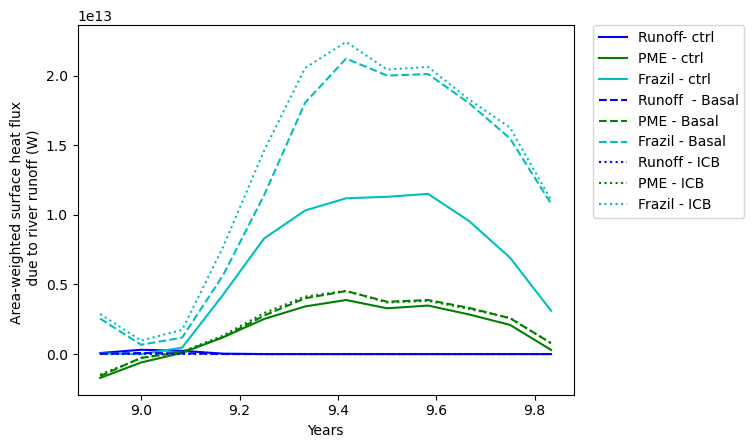

In [27]:
# fig 1: timeseries sfc_hflux_from_runoff area-weighted, averaged horizontally:
time = np.arange(0,120)
time_yr = np.divide(time,12)
plt.plot(time_yr[107:-1],HF_runoff_hint_shelf_ctrl[107:-1], label='Runoff- ctrl',color='b', linestyle='-') # not divided by total area
plt.plot(time_yr[107:-1],HF_pme_hint_shelf_ctrl[107:-1], label='PME - ctrl',color='g', linestyle='-') # not divided by total area
plt.plot(time_yr[107:-1],HF_frazil_hint_shelf_ctrl[107:-1], label='Frazil - ctrl',color='c', linestyle='-') # not divided by total area
plt.plot(time_yr[107:-1],HF_runoff_hint_shelf_BG[107:-1], label='Runoff  - Basal',color='b', linestyle='--') # not divided by total area
plt.plot(time_yr[107:-1],HF_pme_hint_shelf_BG[107:-1], label='PME - Basal',color='g', linestyle='--') # not divided by total area
plt.plot(time_yr[107:-1],HF_frazil_hint_shelf_BG[107:-1], label='Frazil - Basal',color='c', linestyle='--') # not divided by total area
plt.plot(time_yr[107:-1],HF_runoff_hint_shelf_ICB[107:-1], label='Runoff - ICB',color='b', linestyle=':') # not divided by total area
plt.plot(time_yr[107:-1],HF_pme_hint_shelf_ICB[107:-1], label='PME - ICB',color='g', linestyle=':') # not divided by total area
plt.plot(time_yr[107:-1],HF_frazil_hint_shelf_ICB[107:-1], label='Frazil - ICB',color='c', linestyle=':') # not divided by total area


plt.legend(bbox_to_anchor=(1.04, 1), borderaxespad=0)
plt.xlabel('Years')
plt.ylabel('Area-weighted surface heat flux \n due to river runoff (W)')

Text(0, 0.5, 'Area-weighted surface heat flux \n due to river runoff (W)')

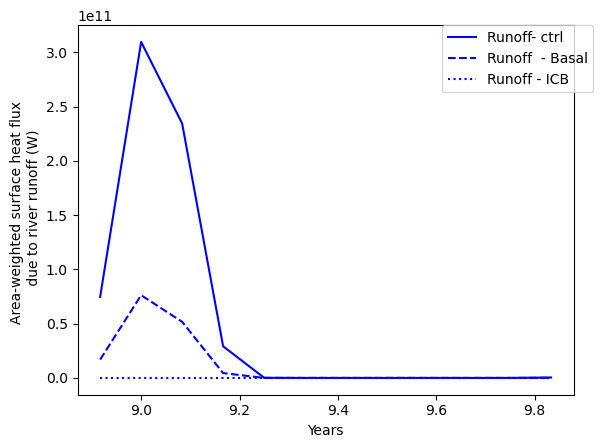

In [28]:
# fig 1: timeseries sfc_hflux_from_runoff area-weighted, averaged horizontally:
time = np.arange(0,120)
time_yr = np.divide(time,12)
plt.plot(time_yr[107:-1],HF_runoff_hint_shelf_ctrl[107:-1], label='Runoff- ctrl',color='b', linestyle='-') # not divided by total area
plt.plot(time_yr[107:-1],HF_runoff_hint_shelf_BG[107:-1], label='Runoff  - Basal',color='b', linestyle='--') # not divided by total area
plt.plot(time_yr[107:-1],HF_runoff_hint_shelf_ICB[107:-1], label='Runoff - ICB',color='b', linestyle=':') # not divided by total area

plt.legend(bbox_to_anchor=(1.04, 1), borderaxespad=0)
plt.xlabel('Years')
plt.ylabel('Area-weighted surface heat flux \n due to river runoff (W)')

In [29]:
time_yr[107:-1].shape

(12,)